# AdaptiveMath-AI — Preprocessing, Past-Only Features, and Evaluation Splits

**Notebook 02 of 06**

The official Eedi data are converted into a deterministic modeling cohort with temporal and entity-disjoint splits. Every response-derived predictor is constructed from observations available strictly before the current target.

## 1. Environment, visual contract, and frozen configuration

Reconfirm resources and load the pre-registered design from Notebook 01. Use the same seed, paths, typography, and 16 GiB memory constraint; define every helper locally.

Leakage control: Split and cohort parameters are read before model outcomes exist.

In [1]:
from pathlib import Path
import ast, json, math, os, sys, time, textwrap, warnings, hashlib
from collections import defaultdict, Counter, deque
from datetime import datetime, timezone
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
import psutil
from scipy import sparse
from sklearn.decomposition import TruncatedSVD

mpl.rcParams.update({"font.family":"Times New Roman","font.size":18,"axes.titlesize":20,"axes.labelsize":19,"xtick.labelsize":18,"ytick.labelsize":18,"legend.fontsize":18,"figure.titlesize":20,"axes.spines.top":False,"axes.spines.right":False,"savefig.dpi":350,"figure.dpi":350})
PALETTE={"blue":"#2F6B8F","orange":"#C77C2B","green":"#4F7F3A","purple":"#6D5A8D","red":"#B45A55","gray":"#6E7378","light_gray":"#E7EAED","teal":"#4A8C8A","gold":"#C9A227","black":"#222222","white":"#FFFFFF"}
SEED=20260713; np.random.seed(SEED)
cwd=Path.cwd().resolve(); ROOT=next((p for p in [cwd,*cwd.parents] if (p/"notebooks").is_dir() and (p/"README.md").exists()),None)
if ROOT is None: raise FileNotFoundError("Run from the repository root or the notebooks directory.")
config=json.loads((ROOT/"artifacts/experiment_config.json").read_text(encoding="utf-8"))
vm=psutil.virtual_memory()
try:
 import torch; mps_available=bool(torch.backends.mps.is_available())
except Exception: mps_available=False
resources=pd.DataFrame([{"available_ram_gib":vm.available/2**30,"total_ram_gib":vm.total/2**30,"cpu_count":psutil.cpu_count(),"mps_available":mps_available,"cohort_cap":config["cohort_policy"]["max_interactions"]}])
display(resources); display(pd.DataFrame([config["cohort_policy"]]))
print(f"Project root: {ROOT}")

,available_ram_gib,total_ram_gib,cpu_count,mps_available,cohort_cap
0,4.42421,16.0,10,True,600000


,max_students,max_interactions,minimum_student_interactions,selection,same_cohort_all_comparable_models
0,12000,600000,20,deterministic stratified hash/activity selecti...,True


Project root: <repository_root>


### Notebook-local figure helpers

Keep plot production reproducible without forbidden external helpers. Define high-resolution export, label wrapping, bar annotation, ranking, and legend placement in this notebook.

Leakage control: Helpers consume only explicitly supplied summaries.

In [2]:
def save_and_show_figure(fig, filename):
 path=ROOT/"figures"/filename; fig.savefig(path,dpi=350,bbox_inches="tight",facecolor="white"); plt.show(); print(f"Saved figure: {path}"); return path
def annotate_bars(ax,fmt="{:.3f}"):
 for p in ax.patches:
  if abs(p.get_width())>0: ax.text(p.get_x()+p.get_width(),p.get_y()+p.get_height()/2," "+fmt.format(p.get_width()),va="center",clip_on=False)
  else: ax.text(p.get_x()+p.get_width()/2,p.get_height(),fmt.format(p.get_height()),ha="center",va="bottom",clip_on=False)
def wrap_labels(labels,width=28): return ["\n".join(textwrap.wrap(str(x).replace("_"," "),width)) for x in labels]
def plot_horizontal_metric_ranking(frame,label_col,metric_col,color=PALETTE["blue"]):
 d=frame.sort_values(metric_col); fig,ax=plt.subplots(figsize=(10,max(4,.45*len(d)))); ax.barh(wrap_labels(d[label_col]),d[metric_col],color=color,edgecolor=PALETTE["black"]); ax.grid(axis="x",color=PALETTE["light_gray"]); annotate_bars(ax); return fig,ax
def place_legend_below(ax,ncol=3): ax.legend(loc="upper center",bbox_to_anchor=(.5,-.16),ncol=ncol,frameon=False)
def stable_hash(values,salt=""):
 return pd.util.hash_pandas_object(values.astype(str)+salt,index=False).astype("uint64")
print("Figure helpers defined locally.")

Figure helpers defined locally.


## 2. Typed full-data conversion and deterministic cohort selection

Preserve a reusable columnar version of the full labeled source while selecting one feasible cohort for all comparable models. Materialize only six compact interaction columns, write compressed Parquet with bounded row groups, require at least 20 responses per student, stratify selection by activity quintile, and cap the cohort near 450,000 complete histories.

Leakage control: Selection uses identifiers and activity counts only—not labels, validation performance, or test results. Full student histories are retained once selected.

In [3]:
raw_root=ROOT/"dataset/raw/extracted"
def locate(pattern):
 matches=sorted(p for p in raw_root.rglob(pattern) if not p.name.startswith("._") and "__MACOSX" not in p.parts)
 if not matches: raise FileNotFoundError(pattern)
 return matches[0]
train_path=locate("train_task_1_2.csv"); answer_path=locate("answer_metadata_task_1_2.csv"); student_path=locate("student_metadata_task_1_2.csv"); question_path=locate("question_metadata_task_1_2.csv"); subject_path=locate("subject_metadata.csv")
dtypes={"QuestionId":"int32","UserId":"int32","AnswerId":"int32","IsCorrect":"int8","CorrectAnswer":"int8","AnswerValue":"int8"}
raw=pd.read_csv(train_path,dtype=dtypes)
clean_path=ROOT/"dataset/processed/interactions_cleaned.parquet"
raw.to_parquet(clean_path,index=False,compression="zstd",row_group_size=500_000)
print(f"Saved full row-group-partitioned Parquet: {clean_path} ({clean_path.stat().st_size/2**20:.1f} MiB)")
counts=raw.groupby("UserId").size().rename("interaction_count").reset_index()
eligible=counts[counts.interaction_count>=config["cohort_policy"]["minimum_student_interactions"]].copy()
eligible["activity_bin"]=pd.qcut(eligible.interaction_count.rank(method="first"),5,labels=["very_low","low","medium","high","very_high"])
eligible["hash"]=stable_hash(eligible.UserId,"cohort")
per_bin_budget=90_000; max_students=config["cohort_policy"]["max_students"]//5
selected_parts=[]
for level,g in eligible.groupby("activity_bin",observed=True):
 g=g.sort_values("hash"); cumulative=g.interaction_count.cumsum(); chosen=g[cumulative<=per_bin_budget].head(max_students)
 if chosen.empty: chosen=g.head(1)
 selected_parts.append(chosen)
selected_students=pd.concat(selected_parts,ignore_index=True)
selected_ids=set(selected_students.UserId.astype(int))
cohort=raw[raw.UserId.isin(selected_ids)].copy()
print(f"Selected {len(selected_students):,} complete student histories and {len(cohort):,} interactions ({len(cohort)/len(raw):.2%} of labeled data).")
display(selected_students.groupby("activity_bin",observed=True).agg(students=("UserId","size"),interactions=("interaction_count","sum"),median_history=("interaction_count","median")).reset_index())
del raw

Saved full row-group-partitioned Parquet: <repository_root>/dataset/processed/interactions_cleaned.parquet (149.6 MiB)


Selected 5,380 complete student histories and 449,557 interactions (2.83% of labeled data).


,activity_bin,students,interactions,median_history
0,very_low,1997,89964,45.0
1,low,1460,89953,61.0
2,medium,1015,89939,88.0
3,high,638,89967,138.0
4,very_high,270,89734,288.0


## 3. Memory-safe metadata joins and subject hierarchy representation

Recover chronology, educational context, demographics, and mathematical concepts for selected interactions. Stream-filter answer metadata by selected `AnswerId`, validate one-to-one join coverage, parse question subject lists, and choose the deepest listed concept as the primary subject while retaining ancestor paths.

Leakage control: Current confidence is retained only to construct lagged confidence; it is excluded from predictor columns. Subject structure contains no response labels.

In [4]:
selected_answer_ids=set(cohort.AnswerId.astype(int)); answer_parts=[]
for chunk in pd.read_csv(answer_path,chunksize=1_000_000,low_memory=False):
 ids=pd.to_numeric(chunk["AnswerId"],errors="coerce")
 keep=ids.isin(selected_answer_ids)
 if keep.any():
  part=chunk.loc[keep].copy(); part["AnswerId"]=ids.loc[keep].astype("int32"); answer_parts.append(part)
answer_meta=pd.concat(answer_parts,ignore_index=True)
assert answer_meta.AnswerId.is_unique
cohort=cohort.merge(answer_meta,on="AnswerId",how="left",validate="one_to_one")
join_coverage=cohort.DateAnswered.notna().mean(); assert join_coverage>0.999
cohort["DateAnswered"]=pd.to_datetime(cohort.DateAnswered,errors="coerce",utc=True)

student_meta=pd.read_csv(student_path,low_memory=False)
student_meta["DateOfBirth"]=pd.to_datetime(student_meta.DateOfBirth,errors="coerce",utc=True)
question_meta=pd.read_csv(question_path,low_memory=False)
subject_meta=pd.read_csv(subject_path,low_memory=False)
subject_meta["SubjectId"]=pd.to_numeric(subject_meta.SubjectId,errors="coerce").astype("Int64")
subject_meta["ParentId"]=pd.to_numeric(subject_meta.ParentId,errors="coerce").astype("Int64")
level_map=subject_meta.set_index("SubjectId").Level.to_dict(); parent_map=subject_meta.dropna(subset=["ParentId"]).set_index("SubjectId").ParentId.astype(int).to_dict(); name_map=subject_meta.set_index("SubjectId").Name.to_dict()
def parse_subjects(value):
 try: return [int(x) for x in ast.literal_eval(str(value))]
 except Exception: return []
def ancestor_path(subject_id):
 path=[]; current=int(subject_id) if pd.notna(subject_id) else None; seen=set()
 while current is not None and current not in seen:
  path.append(current); seen.add(current); current=parent_map.get(current)
 return path
question_meta["subject_ids"]=question_meta.SubjectId.map(parse_subjects)
question_meta["number_of_subjects"]=question_meta.subject_ids.map(len)
question_meta["primary_subject_id"]=question_meta.subject_ids.map(lambda xs:max(xs,key=lambda x:(level_map.get(x,-1),x)) if xs else -1)
question_meta["subject_depth"]=question_meta.primary_subject_id.map(lambda x:level_map.get(x,-1))
question_meta["parent_subject_id"]=question_meta.primary_subject_id.map(lambda x:parent_map.get(x,-1))
question_meta["ancestor_path"]=question_meta.primary_subject_id.map(ancestor_path)
question_meta["primary_subject_name"]=question_meta.primary_subject_id.map(lambda x:name_map.get(x,"Unknown"))
question_features=question_meta[["QuestionId","subject_ids","number_of_subjects","primary_subject_id","primary_subject_name","subject_depth","parent_subject_id","ancestor_path"]]
cohort=cohort.merge(question_features,on="QuestionId",how="left",validate="many_to_one")
cohort=cohort.merge(student_meta,on="UserId",how="left",validate="many_to_one")
cohort["age_at_answer"]=((cohort.DateAnswered-cohort.DateOfBirth).dt.total_seconds()/(365.2425*86400)).where(lambda s:s.between(4,25))
cohort=cohort.sort_values(["UserId","DateAnswered","AnswerId"],kind="mergesort").reset_index(drop=True)
cohort["interaction_id"]=np.arange(len(cohort),dtype="int64")

edge_rows=[]
for _,r in subject_meta.iterrows():
 if pd.notna(r.ParentId): edge_rows.append({"source_subject_id":int(r.ParentId),"target_subject_id":int(r.SubjectId),"edge_type":"parent_child","source_name":name_map.get(int(r.ParentId),"Unknown"),"target_name":r.Name})
graph=pd.DataFrame(edge_rows); graph_path=ROOT/"dataset/processed/question_subject_graph.parquet"; graph.to_parquet(graph_path,index=False)
print(f"Answer metadata join coverage: {join_coverage:.4%}; date range {cohort.DateAnswered.min()} to {cohort.DateAnswered.max()}")
display(cohort[["QuestionId","UserId","AnswerId","DateAnswered","primary_subject_name","subject_depth","Gender","PremiumPupil"]].head())
print(f"Saved subject graph: {graph_path} ({graph_path.stat().st_size/1024:.1f} KiB)")

Answer metadata join coverage: 100.0000%; date range 2018-09-01 00:53:00+00:00 to 2020-04-29 10:11:00+00:00


,QuestionId,UserId,AnswerId,DateAnswered,primary_subject_name,subject_depth,Gender,PremiumPupil
0,590,3,7063199,2019-02-01 11:10:00+00:00,Experimental Probability and Relative Frequency,3,1,NaN
1,10040,3,2074004,2019-02-02 20:23:00+00:00,BIDMAS,3,1,NaN
2,2068,3,9047690,2019-02-02 20:25:00+00:00,Expanding Double Brackets,3,1,NaN
3,16297,3,7545385,2019-02-02 20:28:00+00:00,Other Sequences,3,1,NaN
4,915,3,8496724,2019-02-02 20:29:00+00:00,Averages and Range from Grouped Data,3,1,NaN


Saved subject graph: <repository_root>/dataset/processed/question_subject_graph.parquet (13.3 KiB)


## 4. Frozen temporal and cold-start assignments

Separate future-interaction prediction from student and question cold start. Select about 5% of cohort students within activity/demographic strata as complete external holdouts; select about 5% of cohort questions within primary subjects; assign all remaining interactions per student to earliest 70%, next 15%, and latest 15%.

Leakage control: Student and question holdouts are chosen before feature construction. No holdout label affects cohort or entity selection.

In [5]:
profile=selected_students.merge(student_meta[["UserId","Gender","PremiumPupil"]],on="UserId",how="left")
profile["gender_stratum"]=profile.Gender.fillna(-1).astype(str); profile["premium_stratum"]=profile.PremiumPupil.fillna(-1).astype(str)
profile["holdout_stratum"]=profile.activity_bin.astype(str)+"|"+profile.gender_stratum+"|"+profile.premium_stratum
profile["holdout_hash"]=stable_hash(profile.UserId,"external_student")
external_user_parts=[]
for _,g in profile.groupby("holdout_stratum"):
 n=max(1,int(round(.05*len(g)))); external_user_parts.append(g.nsmallest(n,"holdout_hash"))
external_users=set(pd.concat(external_user_parts).UserId.astype(int))

candidate_questions=cohort.loc[~cohort.UserId.isin(external_users),["QuestionId","primary_subject_id"]].drop_duplicates()
candidate_questions["q_hash"]=stable_hash(candidate_questions.QuestionId,"external_question")
external_question_parts=[]
for _,g in candidate_questions.groupby("primary_subject_id"):
 n=max(1,int(round(.05*len(g)))); external_question_parts.append(g.nsmallest(min(n,len(g)),"q_hash"))
external_questions=set(pd.concat(external_question_parts).QuestionId.astype(int))

cohort["split_id"]=""
cohort.loc[cohort.UserId.isin(external_users),"split_id"]="external_unseen_student"
cohort.loc[(cohort.split_id=="") & cohort.QuestionId.isin(external_questions),"split_id"]="external_unseen_question"
main_mask=cohort.split_id.eq("")
cohort.loc[main_mask,"main_position"]=cohort.loc[main_mask].groupby("UserId").cumcount()
cohort.loc[main_mask,"main_count"]=cohort.loc[main_mask].groupby("UserId").UserId.transform("size")
train_end=np.floor(.70*cohort.loc[main_mask,"main_count"]).astype(int).clip(lower=5)
val_end=np.floor(.85*cohort.loc[main_mask,"main_count"]).astype(int)
pos=cohort.loc[main_mask,"main_position"].astype(int)
labels=np.where(pos<train_end,"train",np.where(pos<val_end,"validation","temporal_test"))
cohort.loc[main_mask,"split_id"]=labels
assert not cohort.loc[cohort.split_id=="train","UserId"].isin(external_users).any()
assert not cohort.loc[cohort.split_id=="train","QuestionId"].isin(external_questions).any()

split_summary=(cohort.groupby("split_id").agg(interactions=("AnswerId","size"),students=("UserId","nunique"),questions=("QuestionId","nunique"),correct_rate=("IsCorrect","mean"),date_min=("DateAnswered","min"),date_max=("DateAnswered","max")).reset_index())
split_summary.to_csv(ROOT/"artifacts/split_summary.csv",index=False); split_summary.to_csv(ROOT/"dataset/processed/split_summary.csv",index=False)
# Pairwise entity-overlap and cold-start checks.
split_names=split_summary.split_id.tolist(); overlap=[]
for i,a in enumerate(split_names):
 for b in split_names[i+1:]:
  A=cohort[cohort.split_id==a]; B=cohort[cohort.split_id==b]
  overlap.append({"split_a":a,"split_b":b,"student_overlap":len(set(A.UserId)&set(B.UserId)),"question_overlap":len(set(A.QuestionId)&set(B.QuestionId))})
overlap=pd.DataFrame(overlap); overlap.to_csv(ROOT/"artifacts/split_overlap_check.csv",index=False)
temporal=[]
for user,g in cohort[cohort.split_id.isin(["train","validation","temporal_test"])].groupby("UserId"):
 dates={s:g.loc[g.split_id==s,"DateAnswered"] for s in ["train","validation","temporal_test"]}
 temporal.append({"UserId":user,"train_before_validation":bool(dates["train"].max()<=dates["validation"].min()) if len(dates["validation"]) else True,"validation_before_test":bool(dates["validation"].max()<=dates["temporal_test"].min()) if len(dates["validation"]) and len(dates["temporal_test"]) else True})
temporal=pd.DataFrame(temporal); temporal.to_csv(ROOT/"artifacts/temporal_leakage_check.csv",index=False)
external_summary=split_summary[split_summary.split_id.str.startswith("external")].copy(); external_summary.to_csv(ROOT/"artifacts/external_test_summary.csv",index=False)
display(split_summary); display(overlap); display(temporal.agg({"train_before_validation":"mean","validation_before_test":"mean"}).to_frame("pass_rate"))
print(f"External users: {len(external_users):,}; external questions: {len(external_questions):,}")
print("Saved split_summary.csv, split_overlap_check.csv, temporal_leakage_check.csv, and external_test_summary.csv")

,split_id,interactions,students,questions,correct_rate,date_min,date_max
0,external_unseen_question,21452,4869,1390,0.633181,2018-09-01 00:53:00+00:00,2020-04-29 09:51:00+00:00
1,external_unseen_student,22687,271,12302,0.659144,2018-09-03 00:32:00+00:00,2020-04-29 10:05:00+00:00
2,temporal_test,63209,5109,17031,0.613267,2018-09-02 21:53:00+00:00,2020-04-29 10:11:00+00:00
3,train,281459,5109,23585,0.651711,2018-09-01 01:03:00+00:00,2020-04-29 09:34:00+00:00
4,validation,60750,5109,16966,0.634700,2018-09-01 15:28:00+00:00,2020-04-29 09:43:00+00:00


,split_a,split_b,student_overlap,question_overlap
0,external_unseen_question,external_unseen_student,0,645
1,external_unseen_question,temporal_test,4869,0
2,external_unseen_question,train,4869,0
3,external_unseen_question,validation,4869,0
4,external_unseen_student,temporal_test,0,9468
5,external_unseen_student,train,0,11323
6,external_unseen_student,validation,0,9519
7,temporal_test,train,5109,16104
8,temporal_test,validation,5109,13366
9,train,validation,5109,16160


,pass_rate
train_before_validation,1.0
validation_before_test,1.0


External users: 271; external questions: 1,390
Saved split_summary.csv, split_overlap_check.csv, temporal_leakage_check.csv, and external_test_summary.csv


## 5. Strictly prior student, temporal, context, and concept features

Represent evolving knowledge and study context at the moment immediately before each answer. Use stable within-student chronology, shifted cumulative/rolling statistics, lagged confidence, prior active-context counts, session-so-far features, and student–subject histories. Main validation/test and unseen-student scenarios are evaluated prequentially: after a response is predicted and observed, it may update later learner state.

Leakage control: Every outcome/confidence/choice feature is emitted before the current row updates state. External unseen-question targets are stricter: their outcomes never update any later predictive state. Session length means observed length so far, never future session length.

In [6]:
d=cohort.reset_index(drop=True)
# Prediction-state contract: an external unseen-question response is a target only.
# It never updates learner, concept, confidence, answer-choice, session, Elo, or BKT state.
d["history_eligible"]=(~d.split_id.eq("external_unseen_question")).astype("int8")
n=len(d); conf=pd.to_numeric(d.Confidence,errors="coerce"); d["missing_confidence"]=conf.isna().astype("int8")
prior_n=np.zeros(n,dtype="int32"); prior_correct=np.zeros(n,dtype="int32")
rolling={w:np.full(n,.5,dtype="float32") for w in [5,10,20,50]}; ewm=np.full(n,.5,dtype="float32")
prior_conf=np.full(n,np.nan,dtype="float32"); previous_time=np.full(n,pd.NaT,dtype=object)
prior_subj_n=np.zeros(n,dtype="int32"); prior_subj_correct=np.zeros(n,dtype="int32"); previous_subj_time=np.full(n,pd.NaT,dtype=object)
active_days=np.zeros(n,dtype="int32"); group_counts=np.zeros(n,dtype="int32"); quiz_counts=np.zeros(n,dtype="int32"); scheme_counts=np.zeros(n,dtype="int32")
choice_counts={k:np.zeros(n,dtype="int32") for k in [1,2,3,4]}; correct_streak=np.zeros(n,dtype="int16"); error_streak=np.zeros(n,dtype="int16")
session_id=np.zeros(n,dtype="int32"); session_position=np.zeros(n,dtype="int16"); new_session=np.zeros(n,dtype="int8")
for _,idx in d.groupby("UserId",sort=False).groups.items():
 count=correct=cs=es=0; recent=deque(maxlen=50); ewm_state=None; conf_sum=0.; conf_n=0; last_time=None; sid=-1; spos=0
 seen_days=set(); seen_groups=set(); seen_quizzes=set(); seen_schemes=set(); answer_counts=Counter(); subject_state=defaultdict(lambda:[0,0,None])
 for i in idx:
  now=d.at[i,"DateAnswered"]; subj=int(d.at[i,"primary_subject_id"]); sn,sc,st=subject_state[subj]
  prior_n[i]=count; prior_correct[i]=correct; prior_conf[i]=conf_sum/conf_n if conf_n else np.nan
  for w in rolling: rolling[w][i]=float(np.mean(list(recent)[-w:])) if recent else .5
  ewm[i]=.5 if ewm_state is None else ewm_state; previous_time[i]=last_time if last_time is not None else pd.NaT
  previous_subj_time[i]=st if st is not None else pd.NaT; prior_subj_n[i]=sn; prior_subj_correct[i]=sc
  active_days[i]=len(seen_days); group_counts[i]=len(seen_groups); quiz_counts[i]=len(seen_quizzes); scheme_counts[i]=len(seen_schemes)
  for k in choice_counts: choice_counts[k][i]=answer_counts[k]
  correct_streak[i]=cs; error_streak[i]=es
  gap_days=np.nan if last_time is None else max(0.,(now-last_time).total_seconds()/86400.)
  starts=last_time is None or gap_days>0.0208333
  if starts: sid+=1; spos=0
  else: spos+=1
  session_id[i]=sid; session_position[i]=spos; new_session[i]=int(starts)
  if bool(d.at[i,"history_eligible"]):
   y=int(d.at[i,"IsCorrect"]); count+=1; correct+=y; recent.append(y); ewm_state=float(y) if ewm_state is None else .15*y+.85*ewm_state
   if pd.notna(conf.iat[i]): conf_sum+=float(conf.iat[i]); conf_n+=1
   answer_counts[int(d.at[i,"AnswerValue"])]+=1
   if y: cs+=1; es=0
   else: es+=1; cs=0
   subject_state[subj]=[sn+1,sc+y,now]; last_time=now
   seen_days.add(now.floor("D"))
   if pd.notna(d.at[i,"GroupId"]): seen_groups.add(d.at[i,"GroupId"])
   if pd.notna(d.at[i,"QuizId"]): seen_quizzes.add(d.at[i,"QuizId"])
   if pd.notna(d.at[i,"SchemeOfWorkId"]): seen_schemes.add(d.at[i,"SchemeOfWorkId"])
d["prior_interaction_count"]=prior_n; d["prior_correct_count"]=prior_correct; d["prior_incorrect_count"]=(prior_n-prior_correct).astype("int32")
d["prior_cumulative_accuracy"]=(d.prior_correct_count/d.prior_interaction_count.replace(0,np.nan)).fillna(.5).astype("float32")
for w,a in rolling.items(): d[f"rolling_accuracy_{w}"]=a
d["ewm_accuracy"]=ewm; d["prior_confidence_mean"]=prior_conf
d["previous_timestamp"]=pd.to_datetime(previous_time,utc=True); d["days_since_previous_interaction"]=(d.DateAnswered-d.previous_timestamp).dt.total_seconds().div(86400).clip(lower=0).astype("float32")
d["hour"]=d.DateAnswered.dt.hour.astype("int8"); d["day_of_week"]=d.DateAnswered.dt.dayofweek.astype("int8"); d["month"]=d.DateAnswered.dt.month.astype("int8")
d["academic_term"]=pd.cut(d.month,bins=[0,4,8,12],labels=["spring","summer","autumn"]).astype(str)
d["inactivity_gap"]=(d.days_since_previous_interaction>30).astype("int8"); d["new_session"]=new_session; d["session_id"]=session_id; d["session_position"]=session_position
d["session_length_so_far"]=(d.session_position+1).astype("int16"); d["interaction_position"]=(d.prior_interaction_count+1).astype("int32"); d["active_day_key"]=d.DateAnswered.dt.floor("D")
d["active_learning_days"]=active_days; d["number_of_groups"]=group_counts; d["number_of_quizzes"]=quiz_counts; d["number_of_schemes"]=scheme_counts
d["prior_subject_opportunities"]=prior_subj_n; d["prior_subject_correct"]=prior_subj_correct
d["prior_subject_accuracy"]=(d.prior_subject_correct/d.prior_subject_opportunities.replace(0,np.nan)).fillna(.5).astype("float32")
d["days_since_previous_subject_interaction"]=(d.DateAnswered-pd.to_datetime(previous_subj_time,utc=True)).dt.total_seconds().div(86400).clip(lower=0).astype("float32")
d["recent_learning_trend"]=(d.rolling_accuracy_5-d.rolling_accuracy_20).astype("float32")
for choice in [1,2,3,4]: d[f"prior_answer_choice_{choice}_rate"]=(choice_counts[choice]/pd.Series(prior_n).replace(0,np.nan)).fillna(.25).astype("float32")
d["recent_correct_streak"]=correct_streak; d["recent_error_streak"]=error_streak
# Missing metadata and unseen indicators are explicit.
d["missing_student_metadata"]=(d.Gender.isna() & d.DateOfBirth.isna() & d.PremiumPupil.isna()).astype("int8")
d["missing_demographics"]=(d.Gender.isna() | d.DateOfBirth.isna() | d.PremiumPupil.isna()).astype("int8")
d["missing_context_metadata"]=(d.GroupId.isna() | d.QuizId.isna()).astype("int8")
assert (d.prior_correct_count<=d.prior_interaction_count).all()
eligible_cum=d.history_eligible.groupby(d.UserId).cumsum()-d.history_eligible
assert np.array_equal(d.prior_interaction_count.to_numpy(),eligible_cum.to_numpy())
isolation=d.loc[d.split_id.eq("external_unseen_question"),["interaction_id","UserId","QuestionId","history_eligible"]].copy()
isolation["target_only_no_state_update"]=True; isolation.to_csv(ROOT/"artifacts/history_isolation_check.csv",index=False)
print(f"Constructed target-safe prequential histories for {len(d):,} interactions; {len(isolation):,} external-item targets never update state.")
display(d[["UserId","DateAnswered","IsCorrect","prior_interaction_count","prior_cumulative_accuracy","rolling_accuracy_5","prior_subject_accuracy","recent_correct_streak","recent_error_streak"]].head(12))

Constructed target-safe prequential histories for 449,557 interactions; 21,452 external-item targets never update state.


,UserId,DateAnswered,IsCorrect,prior_interaction_count,prior_cumulative_accuracy,rolling_accuracy_5,prior_subject_accuracy,recent_correct_streak,recent_error_streak
0,3,2019-02-01 11:10:00+00:00,1,0,0.500000,0.500000,0.5,0,0
1,3,2019-02-02 20:23:00+00:00,1,1,1.000000,1.000000,0.5,1,0
2,3,2019-02-02 20:25:00+00:00,0,2,1.000000,1.000000,0.5,2,0
3,3,2019-02-02 20:28:00+00:00,1,3,0.666667,0.666667,0.5,0,1
4,3,2019-02-02 20:29:00+00:00,0,4,0.750000,0.750000,0.5,1,0
5,3,2019-02-02 20:31:00+00:00,1,5,0.600000,0.600000,0.5,0,1
6,3,2019-02-02 20:32:00+00:00,1,6,0.666667,0.600000,0.5,1,0
7,3,2019-02-02 20:33:00+00:00,0,7,0.714286,0.600000,0.5,2,0
8,3,2019-02-02 20:34:00+00:00,1,8,0.625000,0.600000,0.5,0,1
9,3,2019-02-08 18:25:00+00:00,0,9,0.666667,0.600000,0.5,1,0


## 6. Train-only target mappings and psychometric states

Estimate item, subject, and context difficulty plus learner ability without using evaluation labels. Construct five-fold user-group out-of-fold encodings for training rows, all-train mappings for every evaluation row, chronological Elo states for training, fixed train item difficulties thereafter, and scenario-consistent learner updates using only earlier eligible responses.

Leakage control: Training rows never encode their own student fold; validation/test/external rows use mappings learned from `train` only. A current eligible outcome updates state only after feature emission; external unseen-question outcomes never update Elo or BKT state.

In [7]:
train_mask=d.split_id.eq("train"); global_mean=float(d.loc[train_mask,"IsCorrect"].mean())
d["oof_fold"]=(stable_hash(d.UserId,"oof")%5).astype("int8")
def add_oof_mapping(frame,key,name,default=global_mean):
 out=np.full(len(frame),default,dtype="float32")
 train_rows=frame[train_mask]
 for fold in range(5):
  fit=train_rows[train_rows.oof_fold!=fold].groupby(key).IsCorrect.agg(["sum","count"])
  smooth=(fit["sum"]+20*global_mean)/(fit["count"]+20)
  idx=frame.index[train_mask & frame.oof_fold.eq(fold)]; out[idx]=frame.loc[idx,key].map(smooth).fillna(default).astype("float32")
 final=train_rows.groupby(key).IsCorrect.agg(["sum","count"]); final_smooth=(final["sum"]+20*global_mean)/(final["count"]+20)
 idx=frame.index[~train_mask]; out[idx]=frame.loc[idx,key].map(final_smooth).fillna(default).astype("float32")
 frame[name]=out
 return final_smooth, final["count"]
q_acc_map,q_count_map=add_oof_mapping(d,"QuestionId","question_historical_accuracy")
subject_acc_map,_=add_oof_mapping(d,"primary_subject_id","subject_historical_accuracy")
group_acc_map,_=add_oof_mapping(d,"GroupId","historical_group_performance")
quiz_acc_map,_=add_oof_mapping(d,"QuizId","historical_quiz_performance")
scheme_acc_map,_=add_oof_mapping(d,"SchemeOfWorkId","historical_scheme_performance")
d["question_difficulty"]=(1-d.question_historical_accuracy).astype("float32")
d["question_cold_start_indicator"]=(~d.QuestionId.isin(q_acc_map.index)).astype("int8")
d["student_cold_start_indicator"]=(~d.UserId.isin(d.loc[train_mask,"UserId"].unique())).astype("int8")
# Popularity uses past train exposure for training; final train count for evaluation.
d["question_popularity_past"]=0
train_order=d.loc[train_mask].sort_values(["DateAnswered","AnswerId"]).index
past_pop=d.loc[train_order].groupby("QuestionId").cumcount(); d.loc[train_order,"question_popularity_past"]=past_pop.values
nontrain_idx=d.index[~train_mask]; d.loc[nontrain_idx,"question_popularity_past"]=d.loc[nontrain_idx,"QuestionId"].map(q_count_map).fillna(0).astype(int)
d["question_popularity_past"]=d.question_popularity_past.astype("int32")
# Rasch-style logits from past learner accuracy and train-only item accuracy.
def safe_logit(p): return np.log(np.clip(p,1e-4,1-1e-4)/np.clip(1-p,1e-4,1-1e-4))
d["rasch_ability"]=safe_logit((d.prior_correct_count+2)/(d.prior_interaction_count+4)).astype("float32")
d["rasch_question_difficulty"]=(-safe_logit(d.question_historical_accuracy)).astype("float32")
# Elo: emit state before update. Train updates user and item; evaluation updates user only, with item fixed from train.
elo_student=np.zeros(len(d),dtype="float32"); elo_question=np.zeros(len(d),dtype="float32")
student_rating=defaultdict(float); question_rating=defaultdict(float); K=.08
for i in train_order:
 u=int(d.at[i,"UserId"]); q=int(d.at[i,"QuestionId"]); s=student_rating[u]; b=question_rating[q]
 elo_student[i]=s; elo_question[i]=b; pred=1/(1+math.exp(-(s-b))); err=float(d.at[i,"IsCorrect"])-pred
 student_rating[u]=s+K*err; question_rating[q]=b-K*err
for _,idxs in d.loc[~train_mask].groupby("UserId",sort=False).groups.items():
 for i in idxs:
  u=int(d.at[i,"UserId"]); q=int(d.at[i,"QuestionId"]); s=student_rating[u]; b=question_rating.get(q,0.0)
  elo_student[i]=s; elo_question[i]=b; pred=1/(1+math.exp(-(s-b)))
  if bool(d.at[i,"history_eligible"]): student_rating[u]=s+K*(float(d.at[i,"IsCorrect"])-pred)
d["elo_student_ability"]=elo_student; d["elo_question_difficulty"]=(-elo_question).astype("float32"); d["elo_probability"]=(1/(1+np.exp(-(elo_student-elo_question)))).astype("float32")
# BKT-like mastery per learner-concept, updated only after feature emission.
mastery=np.full(len(d),.25,dtype="float32"); state=defaultdict(lambda:.25); slip=.10; guess=.20; learn=.08
for i,row in d.iterrows():
 key=(int(row.UserId),int(row.primary_subject_id)); p=state[key]; mastery[i]=p
 if bool(row.history_eligible):
  if row.IsCorrect==1: posterior=p*(1-slip)/(p*(1-slip)+(1-p)*guess)
  else: posterior=p*slip/(p*slip+(1-p)*(1-guess))
  state[key]=posterior+(1-posterior)*learn
d["bkt_mastery"]=mastery; d["subject_mastery_probability"]=((d.prior_subject_correct+1)/(d.prior_subject_opportunities+2)).astype("float32")
print(f"Global train correctness prior: {global_mean:.4f}; train questions mapped: {len(q_acc_map):,}")
display(d.groupby("split_id")[["question_cold_start_indicator","student_cold_start_indicator","question_difficulty","rasch_ability","bkt_mastery"]].mean())

Global train correctness prior: 0.6517; train questions mapped: 23,585


,question_cold_start_indicator,student_cold_start_indicator,question_difficulty,rasch_ability,bkt_mastery
split_id,,,,,
external_unseen_question,1.000000,0.0,0.348289,0.662497,0.518031
external_unseen_student,0.067924,1.0,0.351026,0.720704,0.540739
temporal_test,0.025898,0.0,0.357823,0.691528,0.535896
train,0.000000,0.0,0.352099,0.655124,0.517011
validation,0.018568,0.0,0.352806,0.702663,0.531461


## 7. Train-only collaborative representations

Capture structural student–question exposure patterns complementary to correctness history. Fit truncated SVD to the binary training exposure matrix, derive item factors, and construct each learner representation from questions already seen before the current interaction.

Leakage control: The matrix contains exposure only—not correctness—and uses training rows only. Per-row student state averages prior question factors, so the current question is excluded. Unseen items use zeros.

In [8]:
train_exposure=d.loc[train_mask,["UserId","QuestionId"]].drop_duplicates()
train_users=np.sort(train_exposure.UserId.unique()); train_questions=np.sort(train_exposure.QuestionId.unique())
u_index={u:i for i,u in enumerate(train_users)}; q_index={q:i for i,q in enumerate(train_questions)}
rows=train_exposure.UserId.map(u_index).to_numpy(); cols=train_exposure.QuestionId.map(q_index).to_numpy(); values=np.ones(len(train_exposure),dtype="float32")
X=sparse.csr_matrix((values,(rows,cols)),shape=(len(train_users),len(train_questions)))
n_components=min(8,max(2,min(X.shape)-1)); svd=TruncatedSVD(n_components=n_components,random_state=SEED,n_iter=7)
student_latent=svd.fit_transform(X).astype("float32"); question_latent=svd.components_.T.astype("float32")
q_factor={int(q):question_latent[i] for i,q in enumerate(train_questions)}
collab_similarity=np.zeros(len(d),dtype="float32"); collab_norm=np.zeros(len(d),dtype="float32")
for _,idxs in d.groupby("UserId",sort=False).groups.items():
 running=np.zeros(n_components,dtype="float64"); n=0
 for i in idxs:
  qv=q_factor.get(int(d.at[i,"QuestionId"]),np.zeros(n_components,dtype="float32")); state_vec=running/max(n,1)
  denom=np.linalg.norm(state_vec)*np.linalg.norm(qv)
  collab_similarity[i]=float(np.dot(state_vec,qv)/denom) if denom>0 else 0.0; collab_norm[i]=float(np.linalg.norm(state_vec))
  if d.at[i,"split_id"]=="train" and int(d.at[i,"QuestionId"]) in q_factor: running+=qv; n+=1
d["student_question_similarity"]=collab_similarity; d["collaborative_state_norm"]=collab_norm; d["matrix_factorization_score"]=(1/(1+np.exp(-3*collab_similarity))).astype("float32")
embedding_rows=[]
for i,u in enumerate(train_users):
 row={"entity_type":"student","entity_id":int(u)}; row.update({f"factor_{j}":float(student_latent[i,j]) for j in range(n_components)}); embedding_rows.append(row)
for i,q in enumerate(train_questions):
 row={"entity_type":"question","entity_id":int(q)}; row.update({f"factor_{j}":float(question_latent[i,j]) for j in range(n_components)}); embedding_rows.append(row)
embeddings=pd.DataFrame(embedding_rows); emb_path=ROOT/"dataset/processed/collaborative_embeddings.parquet"; embeddings.to_parquet(emb_path,index=False)
print(f"Exposure matrix: {X.shape[0]:,} students × {X.shape[1]:,} questions with {X.nnz:,} train-only links")
print(f"Explained SVD variance: {svd.explained_variance_ratio_.sum():.4f}")
print(f"Saved collaborative embeddings: {emb_path} ({emb_path.stat().st_size/2**20:.2f} MiB)")
display(embeddings.head())

Exposure matrix: 5,109 students × 23,585 questions with 281,459 train-only links
Explained SVD variance: 0.0841
Saved collaborative embeddings: <repository_root>/dataset/processed/collaborative_embeddings.parquet (1.77 MiB)


,entity_type,entity_id,factor_0,factor_1,factor_2,factor_3,factor_4,factor_5,factor_6,factor_7
0,student,27,0.100910,0.048528,0.200573,0.160071,0.164811,-0.521093,-0.126824,-0.274660
1,student,88,1.060892,-1.244721,0.080729,0.000150,-0.125228,0.042355,-0.167858,0.071999
2,student,100,0.102061,0.101225,0.017777,-0.009684,0.034597,-0.062128,-0.038237,0.036296
3,student,108,0.432776,0.858253,5.232005,-0.443338,-0.997300,1.626041,0.293370,0.495687
4,student,112,0.031147,0.006959,0.020006,0.132757,0.020379,-0.055915,0.018758,-0.023899


## 8. Sequence artifacts and unified exports

Provide one common tabular dataset and compact model-ready learner sequences. Standardize processed column names, exclude post-answer current confidence from predictors, store one ordered list record per learner, and retain an interaction-to-sequence index.

Leakage control: Sequence labels are stored as targets, but later encoders must use `question[t]` with history only through `t-1`; the index and protocol make that shift inspectable.

In [9]:
# Final processed names are standardized copies; raw names remain unchanged.
rename={"QuestionId":"question_id","UserId":"user_id","AnswerId":"answer_id","IsCorrect":"is_correct","CorrectAnswer":"correct_answer","AnswerValue":"answer_value","DateAnswered":"date_answered","GroupId":"group_id","QuizId":"quiz_id","SchemeOfWorkId":"scheme_of_work_id","Gender":"gender","PremiumPupil":"premium_pupil"}
d.rename(columns=rename,inplace=True)
# Exclude direct post-response/current fields from modeling feature registry.
identifier_cols=["interaction_id","answer_id","user_id","question_id","date_answered","split_id"]
target_col="is_correct"
forbidden_predictors=["is_correct","correct_answer","Confidence","answer_value","missing_confidence","history_eligible","previous_timestamp","DateOfBirth","main_position","main_count","oof_fold","active_day_key"]
feature_cols=[c for c in d.columns if c not in identifier_cols+forbidden_predictors and not isinstance(d[c].dtype,pd.ArrowDtype)]
# Keep lists in unified evidence, but modeling table is scalar-only.
scalar_features=[c for c in feature_cols if not d[c].dtype=="object" or c in ["academic_term","primary_subject_name"]]
model_cols=identifier_cols+[target_col,"primary_subject_id","primary_subject_name"]+sorted(set(scalar_features)-{"primary_subject_id","primary_subject_name","answer_value"})
modeling=d[model_cols].copy()
assert not ({"missing_confidence","history_eligible","Confidence","answer_value","correct_answer","is_correct"}-{"is_correct"}) & (set(modeling.columns)-{target_col})
# Parquet exports.
clean_cohort_path=ROOT/"dataset/processed/interactions_featured.parquet"; d.to_parquet(clean_cohort_path,index=False,compression="zstd")
unified_path=ROOT/"dataset/processed/unified_dataset.parquet"; d.to_parquet(unified_path,index=False,compression="zstd")
modeling_path=ROOT/"dataset/processed/modeling_dataset.parquet"; modeling.to_parquet(modeling_path,index=False,compression="zstd")
# One compact ordered sequence per learner.
sequence_rows=[]; index_rows=[]
for user,g in d.groupby("user_id",sort=False):
 g=g.sort_values(["date_answered","answer_id"])
 sequence_rows.append({"user_id":int(user),"question_ids":[int(x) for x in g.question_id],"subject_ids":[int(x) for x in g.primary_subject_id],"correctness":[int(x) for x in g.is_correct],"answer_choices":[int(x) for x in g.answer_value],"time_gaps_days":[None if pd.isna(x) else float(x) for x in g.days_since_previous_interaction],"confidence_history":[None if pd.isna(x) else float(x) for x in pd.to_numeric(g.Confidence,errors="coerce")],"split_ids":g.split_id.astype(str).tolist(),"interaction_ids":[int(x) for x in g.interaction_id]})
 index_rows.extend({"interaction_id":int(i),"user_id":int(user),"sequence_position":pos,"split_id":str(s)} for pos,(i,s) in enumerate(zip(g.interaction_id,g.split_id)))
sequences=pd.DataFrame(sequence_rows); sequence_index=pd.DataFrame(index_rows)
seq_path=ROOT/"dataset/processed/student_sequences.parquet"; sequences.to_parquet(seq_path,index=False)
seq_unified_path=ROOT/"dataset/processed/sequence_index.parquet"; sequence_index.to_parquet(seq_unified_path,index=False)
# Evaluation copies.
for split in ["external_unseen_student","external_unseen_question"]:
 p=ROOT/"dataset/processed"/f"{split}.parquet"; modeling[modeling.split_id==split].to_parquet(p,index=False)
# Observed-history cohorts: distinct unseen-student rows at exact prior-count values; not same-target truncation.
stress=[]
for cap in [5,10,20,50]:
 temp=modeling[(modeling.split_id=="external_unseen_student") & (modeling.prior_interaction_count==cap)].copy(); temp["history_cap"]=cap; temp["evaluation_split_id"]="stress_short_history"; stress.append(temp)
stress=pd.concat(stress,ignore_index=True) if stress else pd.DataFrame(); stress.to_parquet(ROOT/"dataset/processed/stress_short_history.parquet",index=False)
# Official copies stay supplementary and untouched except split identifier in a processed copy.
for label,pattern in [("official_public_test","test_public_answers_task_1.csv"),("official_private_test","test_private_answers_task_1.csv")]:
 p=locate(pattern); off=pd.read_csv(p); off["split_id"]=label; off.to_parquet(ROOT/"dataset/processed"/f"{label}.parquet",index=False)
print(f"Saved featured cohort: {clean_cohort_path} ({clean_cohort_path.stat().st_size/2**20:.1f} MiB)")
print(f"Saved unified dataset: {unified_path} ({unified_path.stat().st_size/2**20:.1f} MiB)")
print(f"Saved modeling dataset: {modeling_path} ({modeling_path.stat().st_size/2**20:.1f} MiB)")
print(f"Saved sequences: {seq_path} ({seq_path.stat().st_size/2**20:.1f} MiB)")
display(modeling.head()); display(sequences[["user_id","question_ids","correctness","split_ids"]].head(3))

Saved featured cohort: <repository_root>/dataset/processed/interactions_featured.parquet (36.8 MiB)
Saved unified dataset: <repository_root>/dataset/processed/unified_dataset.parquet (36.8 MiB)
Saved modeling dataset: <repository_root>/dataset/processed/modeling_dataset.parquet (33.1 MiB)
Saved sequences: <repository_root>/dataset/processed/student_sequences.parquet (4.3 MiB)


,interaction_id,answer_id,user_id,question_id,date_answered,split_id,is_correct,primary_subject_id,primary_subject_name,academic_term,...,rolling_accuracy_50,scheme_of_work_id,session_id,session_length_so_far,session_position,student_cold_start_indicator,student_question_similarity,subject_depth,subject_historical_accuracy,subject_mastery_probability
0,0,7063199,3,590,2019-02-01 11:10:00+00:00,external_unseen_student,1,110,Experimental Probability and Relative Frequency,spring,...,0.500000,40960.0,0,1,0,1,0.0,3,0.675718,0.5
1,1,2074004,3,10040,2019-02-02 20:23:00+00:00,external_unseen_student,1,33,BIDMAS,spring,...,1.000000,40960.0,1,1,0,1,0.0,3,0.662672,0.5
2,2,9047690,3,2068,2019-02-02 20:25:00+00:00,external_unseen_student,0,51,Expanding Double Brackets,spring,...,1.000000,40960.0,1,2,1,1,0.0,3,0.612651,0.5
3,3,7545385,3,16297,2019-02-02 20:28:00+00:00,external_unseen_student,1,173,Other Sequences,spring,...,0.666667,40960.0,1,3,2,1,0.0,3,0.654600,0.5
4,4,8496724,3,915,2019-02-02 20:29:00+00:00,external_unseen_student,0,103,Averages and Range from Grouped Data,spring,...,0.750000,40960.0,1,4,3,1,0.0,3,0.568713,0.5


,user_id,question_ids,correctness,split_ids
0,3,"[590, 10040, 2068, 16297, 915, 15637, 27197, 1...","[1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, ...","[external_unseen_student, external_unseen_stud..."
1,27,"[23849, 10799, 12271, 19616, 16510, 2497, 2846...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, ...","[external_unseen_question, train, train, train..."
2,88,"[14150, 831, 10117, 9471, 8570, 22523, 2438, 1...","[1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, ...","[train, train, train, train, train, train, tra..."


## 9. Feature dictionary, feature availability and protocol summaries

Make every exported variable and remaining limitation inspectable. Classify features by educational mechanism, measure post-processing missingness and sequence lengths, document cold starts, and write the unification/feature/split protocols.

Leakage control: The dictionary labels forbidden current-response fields and train-only or shifted construction.

In [10]:
def feature_group(c):
 if c in ["question_id","question_difficulty","question_historical_accuracy","question_popularity_past","number_of_subjects","subject_depth","primary_subject_id","parent_subject_id","question_cold_start_indicator"]: return "Current Question"
 if c.startswith("prior_") or c.startswith("rolling_") or c in ["ewm_accuracy","recent_learning_trend","recent_error_streak","recent_correct_streak","active_learning_days","number_of_groups","number_of_quizzes","number_of_schemes"]: return "Student Historical"
 if c.startswith("rasch_") or c.startswith("elo_") or "mastery" in c: return "Psychometric"
 if c in ["hour","day_of_week","month","academic_term","days_since_previous_interaction","days_since_previous_subject_interaction","interaction_position","session_position","session_length_so_far","inactivity_gap"]: return "Temporal"
 if c in ["age_at_answer","gender","premium_pupil","missing_student_metadata","missing_demographics"]: return "Student Metadata"
 if c in ["group_id","quiz_id","scheme_of_work_id","historical_group_performance","historical_quiz_performance","historical_scheme_performance","missing_context_metadata"]: return "Context"
 if "subject" in c or c in ["number_of_subjects","ancestor_path"]: return "Subject Hierarchy"
 if "collabor" in c or "matrix_factor" in c or "similarity" in c: return "Collaborative"
 if c.startswith("missing_"): return "Missingness"
 return "Other"
shifted_features=lambda c:(c.startswith("prior_") or c.startswith("rolling_") or c in ["ewm_accuracy","recent_learning_trend","recent_error_streak","recent_correct_streak","bkt_mastery","elo_student_ability","elo_probability"])
train_fit_features={"question_difficulty","question_historical_accuracy","subject_historical_accuracy","historical_group_performance","historical_quiz_performance","historical_scheme_performance","rasch_question_difficulty","elo_question_difficulty","student_question_similarity","matrix_factorization_score"}
def availability_record(c):
 role="target" if c==target_col else "identifier" if c in identifier_cols else "predictor"
 if role=="target": return {"source_time":"current response","available_before_prediction":False,"fitting_partition":"not a predictor","leakage_control":"excluded from predictors"}
 if shifted_features(c): return {"source_time":"strictly before current target","available_before_prediction":True,"fitting_partition":"prequential eligible history","leakage_control":"emit then update; external-item labels never update state"}
 if c in train_fit_features: return {"source_time":"training history","available_before_prediction":True,"fitting_partition":"student-group OOF train / full train for evaluation","leakage_control":"train-only mapping or representation"}
 return {"source_time":"current question/context before answer","available_before_prediction":True,"fitting_partition":"none or train-only preprocessing","leakage_control":"label-free and known before response"}
feature_dictionary=pd.DataFrame([{"feature":c,"feature_group":feature_group(c),"dtype":str(modeling[c].dtype),"role":"target" if c==target_col else "identifier" if c in identifier_cols else "predictor",**availability_record(c)} for c in modeling.columns])
feature_dictionary.to_csv(ROOT/"dataset/processed/feature_dictionary.csv",index=False)
feature_availability_registry=feature_dictionary[["feature","role","source_time","available_before_prediction","fitting_partition","leakage_control"]].copy()
assert feature_availability_registry.loc[feature_availability_registry.role.eq("predictor"),"available_before_prediction"].all()
feature_availability_registry.to_csv(ROOT/"artifacts/feature_availability_registry.csv",index=False)
target_definition=pd.DataFrame([{"target":"is_correct","positive_value":1,"negative_value":0,"unit":"student-question interaction","prediction_time":"immediately before current answer","current_target_in_input":False}]); target_definition.to_csv(ROOT/"dataset/processed/target_definition.csv",index=False)
feature_group_summary=feature_dictionary[feature_dictionary.role=="predictor"].groupby("feature_group").size().rename("feature_count").reset_index()
feature_missingness=pd.DataFrame({"feature":modeling.columns,"missing_count":[int(modeling[c].isna().sum()) for c in modeling],"missing_rate":[float(modeling[c].isna().mean()) for c in modeling]}).sort_values("missing_rate",ascending=False)
sequence_lengths=sequences.question_ids.map(len); sequence_length_summary=sequence_lengths.describe(percentiles=[.1,.25,.5,.75,.9,.95,.99]).rename("value").reset_index().rename(columns={"index":"statistic"})
cold_start_summary=d.groupby("split_id").agg(interactions=("answer_id","size"),student_cold_start_rate=("student_cold_start_indicator","mean"),question_cold_start_rate=("question_cold_start_indicator","mean")).reset_index()
preprocessing_summary=pd.DataFrame([{"item":"raw_labeled_rows","value":15867850},{"item":"cohort_rows","value":len(d)},{"item":"cohort_students","value":d.user_id.nunique()},{"item":"cohort_questions","value":d.question_id.nunique()},{"item":"answer_metadata_join_coverage","value":join_coverage},{"item":"scalar_model_features","value":len(feature_dictionary[feature_dictionary.role=="predictor"])},{"item":"sequence_users","value":len(sequences)},{"item":"random_seed","value":SEED}])
for name,frame in {"feature_group_summary.csv":feature_group_summary,"feature_missingness_after_processing.csv":feature_missingness,"sequence_length_summary.csv":sequence_length_summary,"cold_start_entity_summary.csv":cold_start_summary}.items(): frame.to_csv(ROOT/"artifacts"/name,index=False); print(f"Saved table: {ROOT/'artifacts'/name}")
preprocessing_summary.to_csv(ROOT/"dataset/processed/preprocessing_summary.csv",index=False)
display(feature_group_summary); display(feature_missingness.head(15)); display(sequence_length_summary); display(cold_start_summary)


Saved table: <repository_root>/artifacts/feature_group_summary.csv
Saved table: <repository_root>/artifacts/feature_missingness_after_processing.csv
Saved table: <repository_root>/artifacts/sequence_length_summary.csv
Saved table: <repository_root>/artifacts/cold_start_entity_summary.csv


,feature_group,feature_count
0,Collaborative,3
1,Context,7
2,Current Question,8
3,Other,3
4,Psychometric,7
5,Student Historical,24
6,Student Metadata,5
7,Subject Hierarchy,2
8,Temporal,10


,feature,missing_count,missing_rate
45,prior_confidence_mean,331023,0.736332
40,premium_pupil,312249,0.694570
67,scheme_of_work_id,287511,0.639543
11,age_at_answer,146822,0.326593
16,days_since_previous_subject_interaction,130511,0.290310
15,days_since_previous_interaction,5714,0.012710
50,prior_subject_accuracy,0,0.000000
55,question_historical_accuracy,0,0.000000
54,question_difficulty,0,0.000000
53,question_cold_start_indicator,0,0.000000


,statistic,value
0,count,5380.000000
1,mean,83.560781
2,std,74.612381
3,min,30.000000
4,10%,42.000000
5,25%,48.000000
6,50%,61.000000
7,75%,90.000000
8,90%,144.000000
9,95%,185.050000


,split_id,interactions,student_cold_start_rate,question_cold_start_rate
0,external_unseen_question,21452,0.0,1.000000
1,external_unseen_student,22687,1.0,0.067924
2,temporal_test,63209,0.0,0.025898
3,train,281459,0.0,0.000000
4,validation,60750,0.0,0.018568


## 10. Comprehensive pre-training data analysis

Characterize the modeling population, quantify associations available to predictors, and detect distributional shift before any model is trained. Compute descriptive statistics, train-only mutual information, point-biserial correlation, Cramér’s V, missingness patterns, Kolmogorov–Smirnov statistics, and Population Stability Index (PSI).

Leakage control: Target associations use `train` only. Validation/test/external labels are not exposed in this analysis; cross-split comparisons use predictor distributions and entity/split counts only.

In [11]:
from scipy.stats import ks_2samp, chi2_contingency
from sklearn.feature_selection import mutual_info_classif

train_eda=d[d.split_id=="train"].copy()
analysis_features=[
 "prior_interaction_count","prior_cumulative_accuracy","rolling_accuracy_5","rolling_accuracy_20",
 "ewm_accuracy","prior_subject_accuracy","question_difficulty","question_popularity_past",
 "rasch_ability","rasch_question_difficulty","elo_probability","bkt_mastery",
 "days_since_previous_interaction","days_since_previous_subject_interaction",
 "recent_learning_trend","recent_error_streak","recent_correct_streak","student_question_similarity",
 "historical_group_performance","historical_quiz_performance","subject_depth","age_at_answer"
]
analysis_features=[c for c in analysis_features if c in train_eda.columns]
pretraining_descriptive=train_eda[analysis_features].describe(percentiles=[.01,.05,.10,.25,.50,.75,.90,.95,.99]).T.reset_index().rename(columns={"index":"feature"})
pretraining_descriptive.to_csv(ROOT/"artifacts/pretraining_descriptive_statistics.csv",index=False)

# Train-only association evidence.
sample=train_eda.sample(n=min(60_000,len(train_eda)),random_state=SEED)
X_assoc=sample[analysis_features].replace([np.inf,-np.inf],np.nan)
X_assoc=X_assoc.fillna(X_assoc.median(numeric_only=True)).fillna(0)
mi=mutual_info_classif(X_assoc,sample.is_correct.astype(int),discrete_features=False,random_state=SEED)
assoc=[]
for j,c in enumerate(analysis_features):
 x=X_assoc[c].to_numpy(float); corr=np.corrcoef(x,sample.is_correct.to_numpy(float))[0,1] if np.nanstd(x)>0 else 0.0
 assoc.append({"feature":c,"mutual_information":float(mi[j]),"point_biserial_correlation":float(corr),"absolute_point_biserial":abs(float(corr)),"evidence_split":"train_only","sample_n":len(sample)})
association_summary=pd.DataFrame(assoc).sort_values("mutual_information",ascending=False)
association_summary.to_csv(ROOT/"artifacts/pretraining_train_association_summary.csv",index=False)

# Cramér's V for categorical train-only associations.
cramers=[]
for c in ["gender","premium_pupil","academic_term","primary_subject_name","month","day_of_week"]:
 if c not in train_eda: continue
 ct=pd.crosstab(train_eda[c].fillna("Missing").astype(str),train_eda.is_correct)
 chi2=chi2_contingency(ct,correction=False)[0]; n=ct.values.sum(); phi2=chi2/max(n,1); r,k=ct.shape
 corrected=max(0,phi2-((k-1)*(r-1))/max(n-1,1)); rcorr=r-((r-1)**2)/max(n-1,1); kcorr=k-((k-1)**2)/max(n-1,1)
 v=math.sqrt(corrected/max(min(kcorr-1,rcorr-1),1e-12))
 cramers.append({"categorical_feature":c,"cramers_v":v,"levels":r,"n":n,"evidence_split":"train_only"})
cramers_summary=pd.DataFrame(cramers).sort_values("cramers_v",ascending=False)
cramers_summary.to_csv(ROOT/"artifacts/pretraining_categorical_association_summary.csv",index=False)

# Predictor-only distribution shift; PSI bins are learned from train.
def psi_against_train(reference,current,bins=10):
 ref=pd.Series(reference).replace([np.inf,-np.inf],np.nan).dropna().to_numpy(float); cur=pd.Series(current).replace([np.inf,-np.inf],np.nan).dropna().to_numpy(float)
 if len(ref)<2 or len(cur)<2: return np.nan
 edges=np.unique(np.quantile(ref,np.linspace(0,1,bins+1)))
 if len(edges)<3: return 0.0
 edges[0],edges[-1]=-np.inf,np.inf
 rp=np.histogram(ref,bins=edges)[0]/len(ref); cp=np.histogram(cur,bins=edges)[0]/len(cur); rp=np.clip(rp,1e-6,None); cp=np.clip(cp,1e-6,None)
 return float(np.sum((cp-rp)*np.log(cp/rp)))
shift_rows=[]
for split_name in ["validation","temporal_test","external_unseen_student","external_unseen_question"]:
 current=d[d.split_id==split_name]
 for c in analysis_features:
  a=train_eda[c].replace([np.inf,-np.inf],np.nan).dropna(); b=current[c].replace([np.inf,-np.inf],np.nan).dropna()
  ks=float(ks_2samp(a.sample(min(len(a),50_000),random_state=SEED),b.sample(min(len(b),50_000),random_state=SEED)).statistic) if len(a) and len(b) else np.nan
  shift_rows.append({"split":split_name,"feature":c,"ks_statistic":ks,"psi":psi_against_train(a,b),"labels_used":False})
shift_summary=pd.DataFrame(shift_rows); shift_summary.to_csv(ROOT/"artifacts/pretraining_distribution_shift_summary.csv",index=False)

missing_by_split=d.groupby("split_id")[analysis_features].apply(lambda g:g.isna().mean()).reset_index()
missing_by_split.to_csv(ROOT/"artifacts/pretraining_missingness_by_split.csv",index=False)
print(f"Saved table: {ROOT/'artifacts/pretraining_descriptive_statistics.csv'}")
print(f"Saved table: {ROOT/'artifacts/pretraining_train_association_summary.csv'}")
print(f"Saved table: {ROOT/'artifacts/pretraining_categorical_association_summary.csv'}")
print(f"Saved table: {ROOT/'artifacts/pretraining_distribution_shift_summary.csv'}")
print(f"Saved table: {ROOT/'artifacts/pretraining_missingness_by_split.csv'}")
display(pretraining_descriptive[["feature","count","mean","std","1%","50%","99%"]].head(15))
display(association_summary.head(15)); display(cramers_summary); display(shift_summary.sort_values("psi",ascending=False).head(15))

Saved table: <repository_root>/artifacts/pretraining_descriptive_statistics.csv
Saved table: <repository_root>/artifacts/pretraining_train_association_summary.csv
Saved table: <repository_root>/artifacts/pretraining_categorical_association_summary.csv
Saved table: <repository_root>/artifacts/pretraining_distribution_shift_summary.csv
Saved table: <repository_root>/artifacts/pretraining_missingness_by_split.csv


,feature,count,mean,std,1%,50%,99%
0,prior_interaction_count,281459.0,49.781396,74.624043,0.000000,27.000000,360.000000
1,prior_cumulative_accuracy,281459.0,0.667158,0.225041,0.000000,0.684211,1.000000
2,rolling_accuracy_5,281459.0,0.651941,0.295565,0.000000,0.600000,1.000000
3,rolling_accuracy_20,281459.0,0.658086,0.240701,0.000000,0.687500,1.000000
4,ewm_accuracy,281459.0,0.657900,0.257307,0.000000,0.691528,1.000000
5,prior_subject_accuracy,281459.0,0.625889,0.308954,0.000000,0.500000,1.000000
6,question_difficulty,281459.0,0.352099,0.091815,0.169166,0.343647,0.614507
7,question_popularity_past,281459.0,14.828511,18.930889,0.000000,9.000000,96.000000
8,rasch_ability,281459.0,0.655124,0.893620,-1.178655,0.613104,2.944439
9,rasch_question_difficulty,281459.0,-0.633116,0.414499,-1.591553,-0.647082,0.466298


,feature,mutual_information,point_biserial_correlation,absolute_point_biserial,evidence_split,sample_n
10,elo_probability,0.072179,0.359811,0.359811,train_only,60000
4,ewm_accuracy,0.062096,0.330582,0.330582,train_only,60000
8,rasch_ability,0.060526,0.327901,0.327901,train_only,60000
3,rolling_accuracy_20,0.060158,0.329861,0.329861,train_only,60000
1,prior_cumulative_accuracy,0.057925,0.324834,0.324834,train_only,60000
2,rolling_accuracy_5,0.057727,0.317397,0.317397,train_only,60000
21,age_at_answer,0.050167,-0.048781,0.048781,train_only,60000
16,recent_correct_streak,0.045273,0.169995,0.169995,train_only,60000
11,bkt_mastery,0.041809,0.224362,0.224362,train_only,60000
5,prior_subject_accuracy,0.037697,0.256161,0.256161,train_only,60000


,categorical_feature,cramers_v,levels,n,evidence_split
3,primary_subject_name,0.129323,287,281459,train_only
1,premium_pupil,0.106097,3,281459,train_only
4,month,0.053607,12,281459,train_only
5,day_of_week,0.032088,7,281459,train_only
0,gender,0.016530,3,281459,train_only
2,academic_term,0.012116,3,281459,train_only


,split,feature,ks_statistic,psi,labels_used
73,external_unseen_question,question_popularity_past,0.916600,12.844765,False
83,external_unseen_question,student_question_similarity,0.980560,12.433847,False
61,external_unseen_student,student_question_similarity,0.980560,12.433847,False
75,external_unseen_question,rasch_question_difficulty,0.524480,12.340295,False
72,external_unseen_question,question_difficulty,0.524480,12.340295,False
22,temporal_test,prior_interaction_count,0.565620,5.690290,False
0,validation,prior_interaction_count,0.490560,4.472623,False
84,external_unseen_question,historical_group_performance,0.255018,1.391707,False
18,validation,historical_group_performance,0.248080,1.294956,False
40,temporal_test,historical_group_performance,0.235180,1.105183,False


## 11. Population coverage, target balance, and activity distributions

Show the scale, temporal coverage, class balance, and long-tailed learner/item activity that motivate robust temporal evaluation. Use annotated horizontal bars, a monthly line chart, and log-scaled histograms with explicit units and non-overlapping labels.

Leakage control: Target balance is shown for training only; activity and timeline figures are label-free.

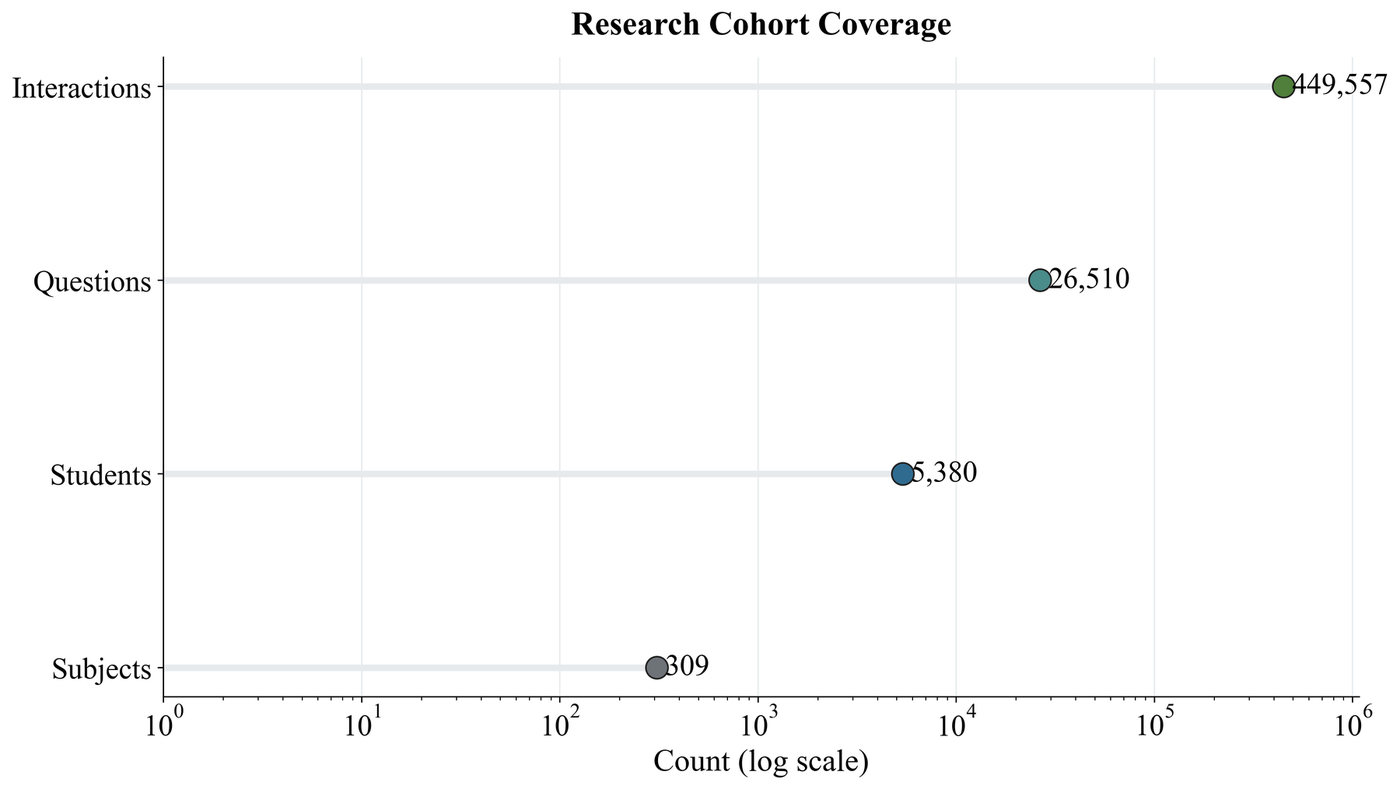

Saved figure: <repository_root>/figures/pretraining_dataset_coverage.png


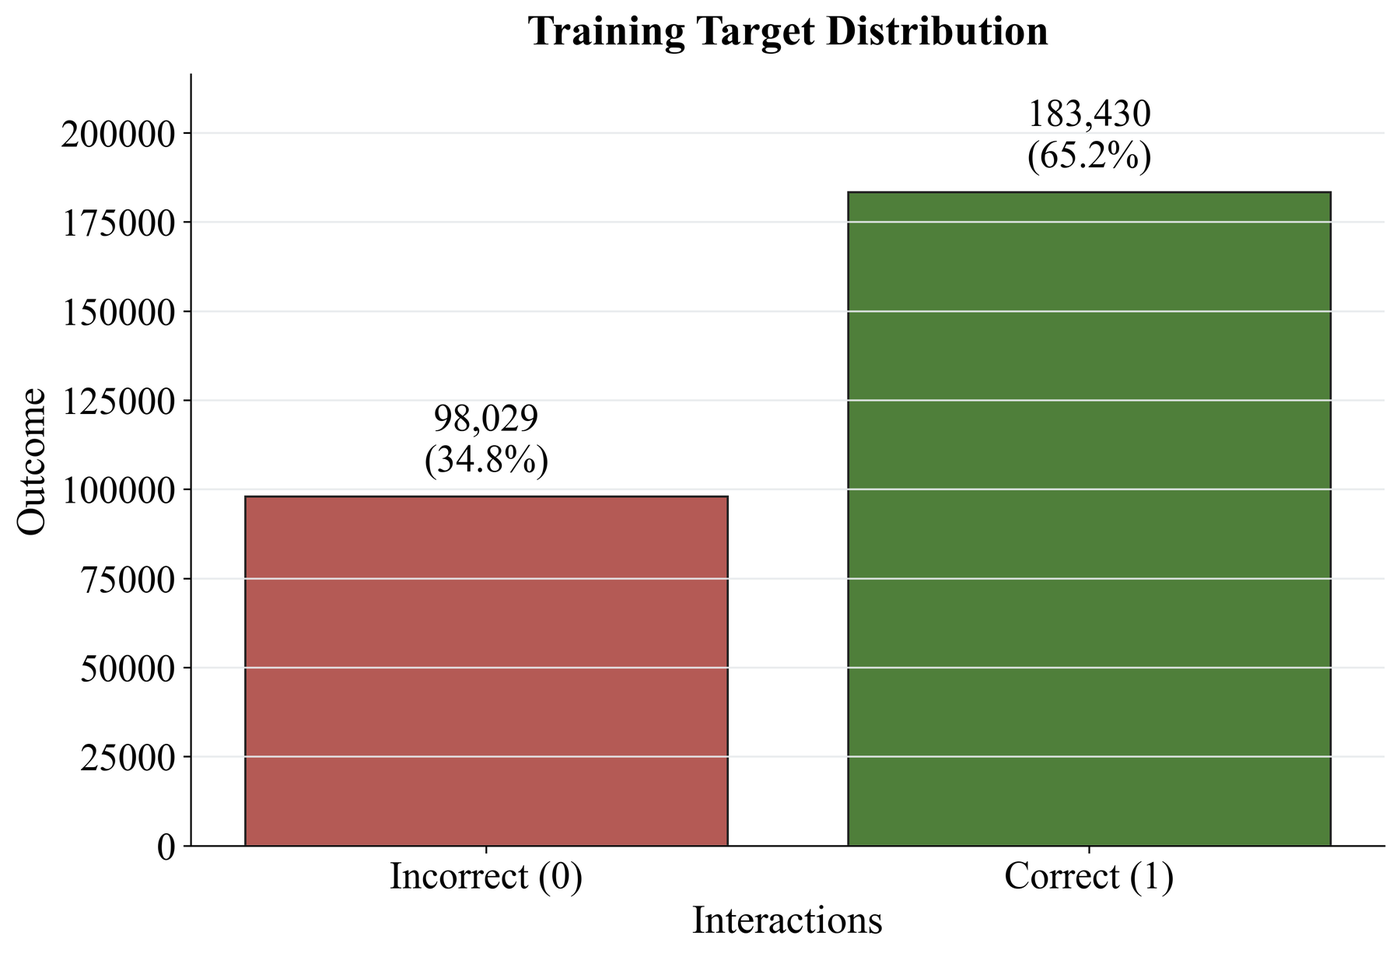

Saved figure: <repository_root>/figures/pretraining_target_distribution_train.png


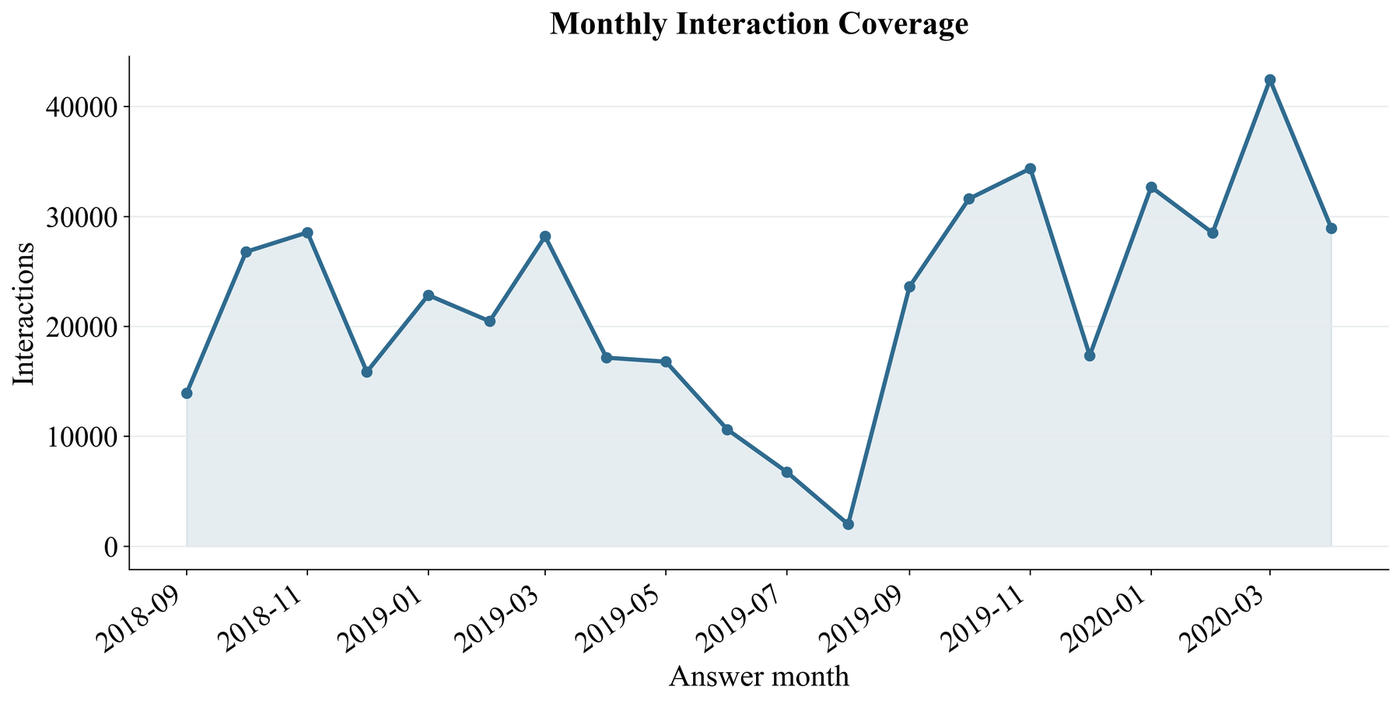

Saved figure: <repository_root>/figures/pretraining_interaction_timeline.png


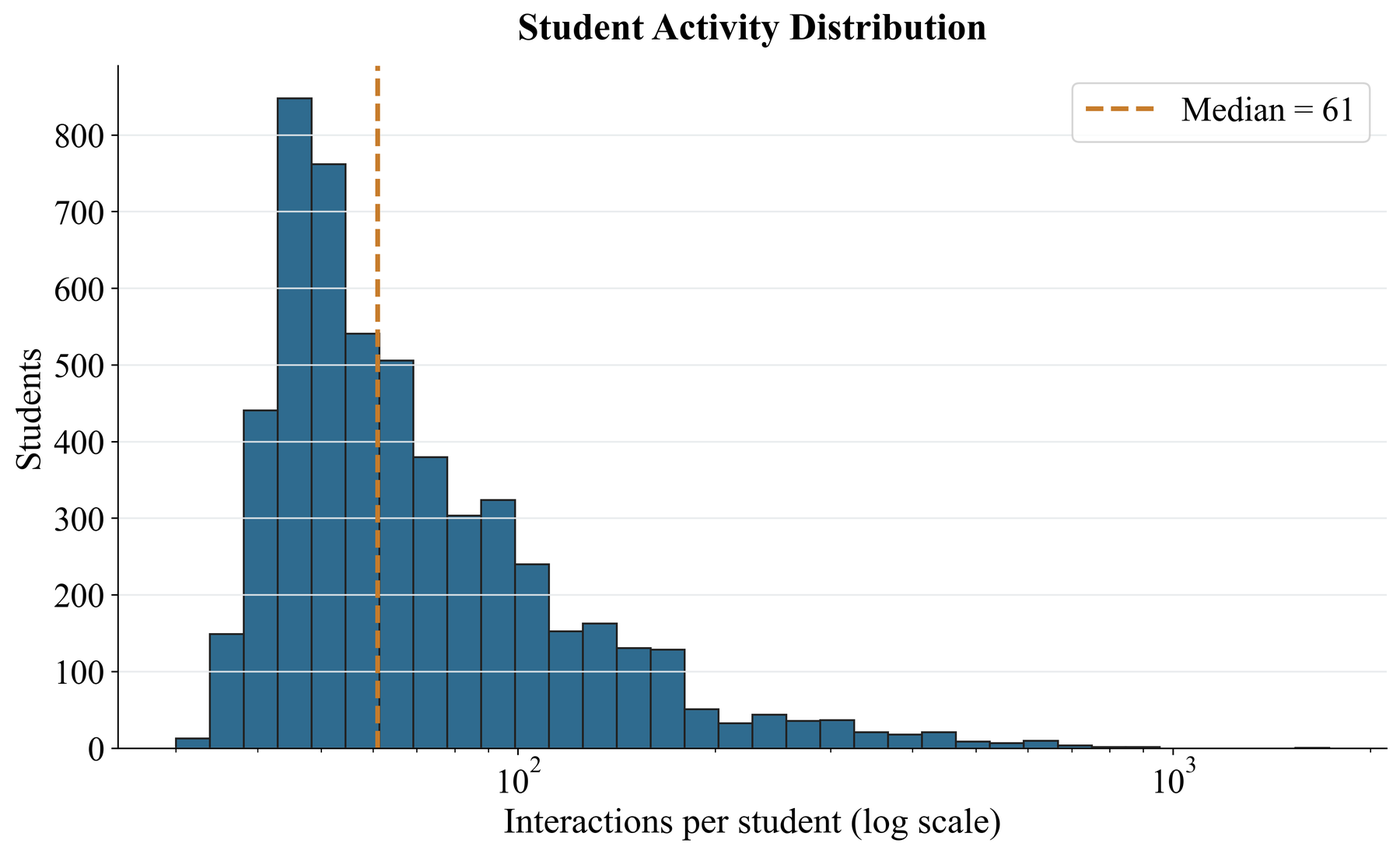

Saved figure: <repository_root>/figures/pretraining_student_activity_histogram.png


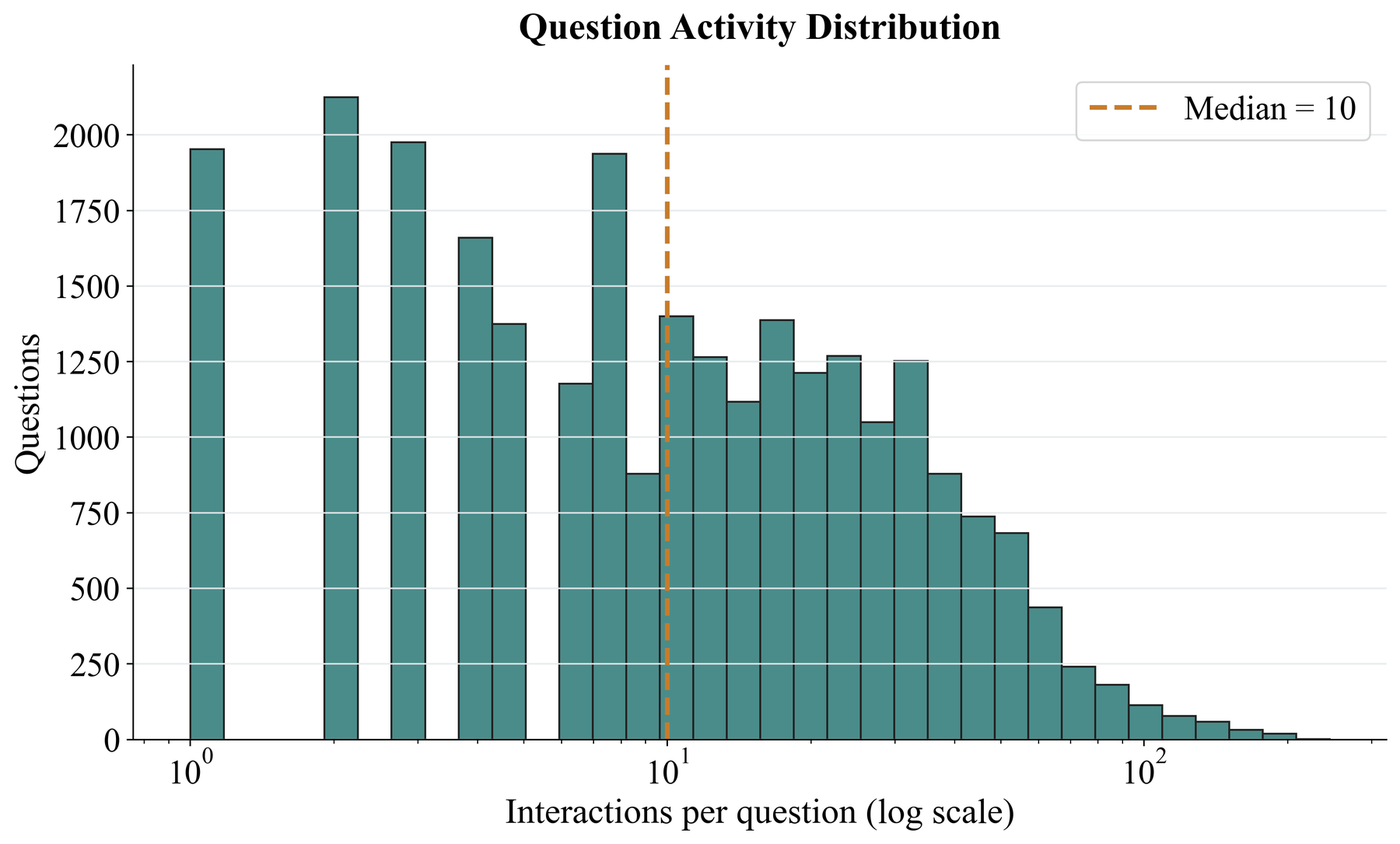

Saved figure: <repository_root>/figures/pretraining_question_activity_histogram.png


In [12]:
visualization_index=[]
def record_figure(filename,question,evidence_boundary): visualization_index.append({"filename":filename,"analytical_question":question,"evidence_boundary":evidence_boundary,"renderer":"Matplotlib","font":"Times New Roman 18–20 pt","dpi":350})
def finish_axes(ax,title,xlabel=None,ylabel=None,grid_axis="x"):
 ax.set_title(title,pad=14,fontweight="bold",fontsize=20)
 if xlabel: ax.set_xlabel(xlabel,fontsize=19)
 if ylabel: ax.set_ylabel(ylabel,fontsize=19)
 ax.tick_params(axis="both",labelsize=18)
 ax.grid(axis=grid_axis,color=PALETTE["light_gray"],linewidth=.9,alpha=.9)

def label_horizontal(ax,fmt="{:,.0f}"):
 xmax=ax.get_xlim()[1]
 for bar in ax.patches:
  ax.text(bar.get_width()+.012*xmax,bar.get_y()+bar.get_height()/2,fmt.format(bar.get_width()),va="center",ha="left",fontsize=18,color=PALETTE["black"],clip_on=False)

# Dataset coverage.
coverage=pd.Series({"Interactions":len(d),"Students":d.user_id.nunique(),"Questions":d.question_id.nunique(),"Subjects":d.primary_subject_id.nunique()}).sort_values()
fig,ax=plt.subplots(figsize=(13,7)); y=np.arange(len(coverage)); colors=[PALETTE["gray"],PALETTE["blue"],PALETTE["teal"],PALETTE["green"]]; ax.hlines(y,1,coverage.values,color=PALETTE["light_gray"],linewidth=4); ax.scatter(coverage.values,y,s=180,color=colors,edgecolor=PALETTE["black"],zorder=3); ax.set_yticks(y,coverage.index); ax.set_xscale("log"); ax.set_xlim(1,max(coverage)*2.4); [ax.text(v*1.10,yi,f"{v:,}",va="center",fontsize=18) for yi,v in zip(y,coverage.values)]; finish_axes(ax,"Research Cohort Coverage","Count (log scale)"); save_and_show_figure(fig,"pretraining_dataset_coverage.png"); record_figure("pretraining_dataset_coverage.png","How broad is the common research cohort?","All cohort rows; log-scale dot plot with exact counts")

# Training target distribution only.
target_counts=train_eda.is_correct.value_counts().reindex([0,1]); labels=["Incorrect (0)","Correct (1)"]
fig,ax=plt.subplots(figsize=(10,6.5)); bars=ax.bar(labels,target_counts.values,color=[PALETTE["red"],PALETTE["green"]],edgecolor=PALETTE["black"])
for b,v in zip(bars,target_counts): ax.text(b.get_x()+b.get_width()/2,v+target_counts.max()*.025,f"{v:,}\n({v/target_counts.sum():.1%})",ha="center",va="bottom",fontsize=18)
finish_axes(ax,"Training Target Distribution","Interactions","Outcome",grid_axis="y"); ax.set_ylim(0,target_counts.max()*1.18); save_and_show_figure(fig,"pretraining_target_distribution_train.png"); record_figure("pretraining_target_distribution_train.png","Is the training target imbalanced?","Training labels only")

# Monthly coverage, label-free.
monthly=d.assign(month_period=d.date_answered.dt.tz_localize(None).dt.to_period("M").dt.to_timestamp()).groupby("month_period").size()
fig,ax=plt.subplots(figsize=(14,6.5)); ax.plot(monthly.index,monthly.values,color=PALETTE["blue"],marker="o",linewidth=2.6,markersize=6); ax.fill_between(monthly.index,monthly.values,color=PALETTE["blue"],alpha=.12); finish_axes(ax,"Monthly Interaction Coverage","Answer month","Interactions",grid_axis="y"); fig.autofmt_xdate(rotation=35); save_and_show_figure(fig,"pretraining_interaction_timeline.png"); record_figure("pretraining_interaction_timeline.png","How does interaction volume vary over time?","All cohort timestamps; labels not used")

# Student activity distribution.
student_activity=d.groupby("user_id").size()
fig,ax=plt.subplots(figsize=(12,6.5)); ax.hist(student_activity,bins=np.logspace(np.log10(student_activity.min()),np.log10(student_activity.max()),35),color=PALETTE["blue"],edgecolor=PALETTE["black"]); ax.set_xscale("log"); finish_axes(ax,"Student Activity Distribution","Interactions per student (log scale)","Students",grid_axis="y"); ax.axvline(student_activity.median(),color=PALETTE["orange"],linewidth=2.5,linestyle="--",label=f"Median = {student_activity.median():.0f}"); ax.legend(fontsize=18); save_and_show_figure(fig,"pretraining_student_activity_histogram.png"); record_figure("pretraining_student_activity_histogram.png","How long and skewed are learner histories?","All cohort identifiers; labels not used")

# Question activity distribution.
question_activity=d.groupby("question_id").size()
fig,ax=plt.subplots(figsize=(12,6.5)); ax.hist(question_activity,bins=np.logspace(np.log10(question_activity.min()),np.log10(question_activity.max()),35),color=PALETTE["teal"],edgecolor=PALETTE["black"]); ax.set_xscale("log"); finish_axes(ax,"Question Activity Distribution","Interactions per question (log scale)","Questions",grid_axis="y"); ax.axvline(question_activity.median(),color=PALETTE["orange"],linewidth=2.5,linestyle="--",label=f"Median = {question_activity.median():.0f}"); ax.legend(fontsize=18); save_and_show_figure(fig,"pretraining_question_activity_histogram.png"); record_figure("pretraining_question_activity_histogram.png","How sparse and long-tailed is item exposure?","All cohort identifiers; labels not used")

## 12. Missingness, demographics, time gaps, and calendar structure

Diagnose incomplete metadata and temporal behavior that can destabilize prediction or subgroup comparisons. Render a split-by-feature missingness matrix, age and time-gap histograms, a month–weekday activity matrix, and contextual missingness bars.

Leakage control: These plots use feature availability and timestamps; demographic outcome relationships are not shown outside training.

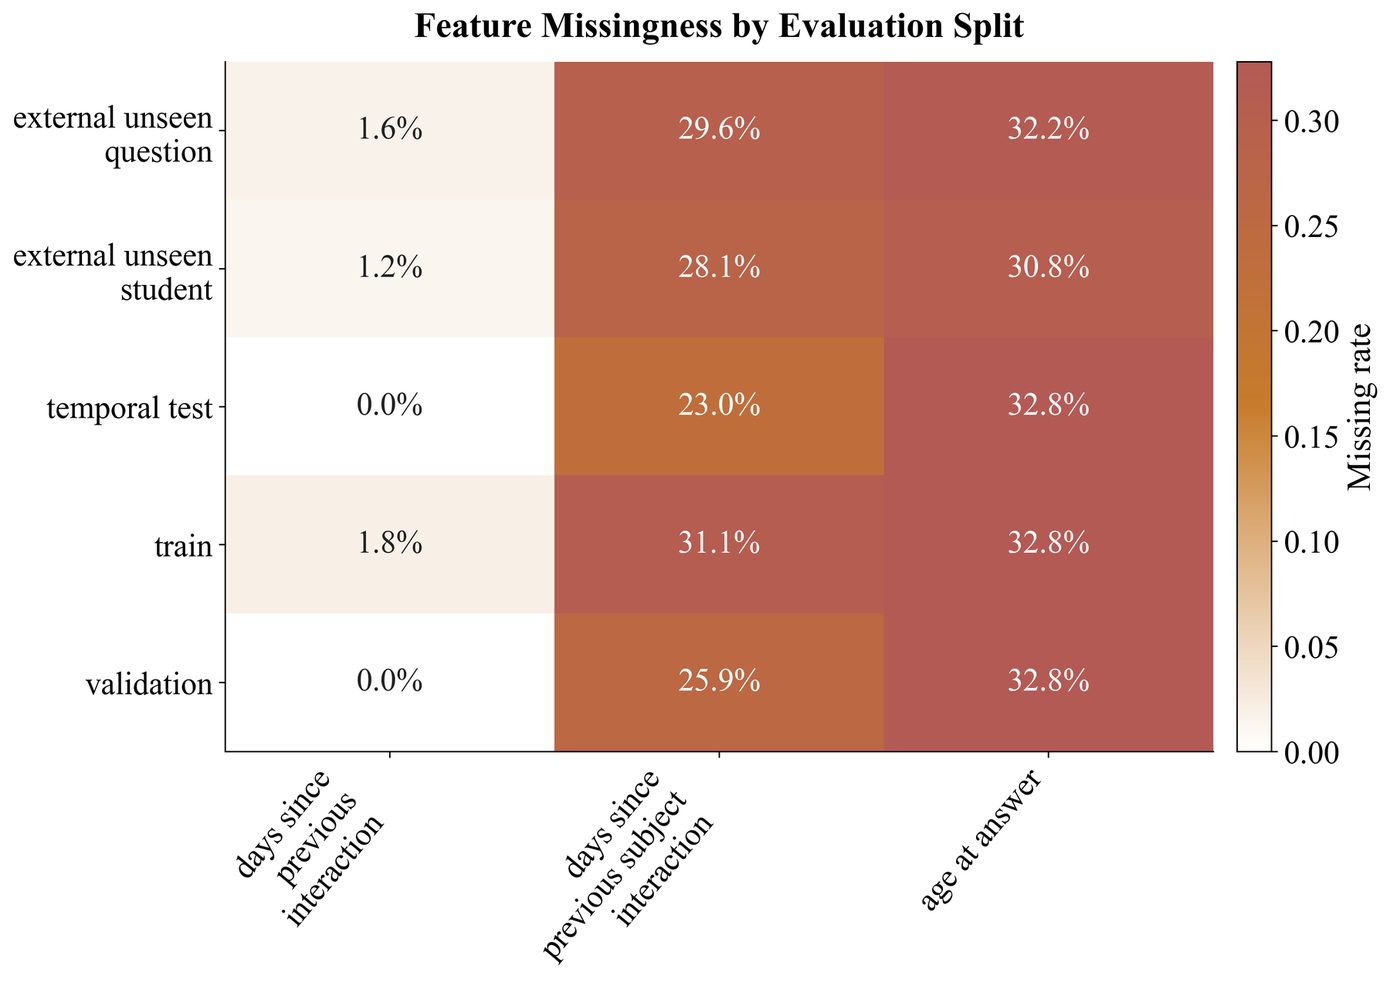

Saved figure: <repository_root>/figures/pretraining_missingness_matrix.png


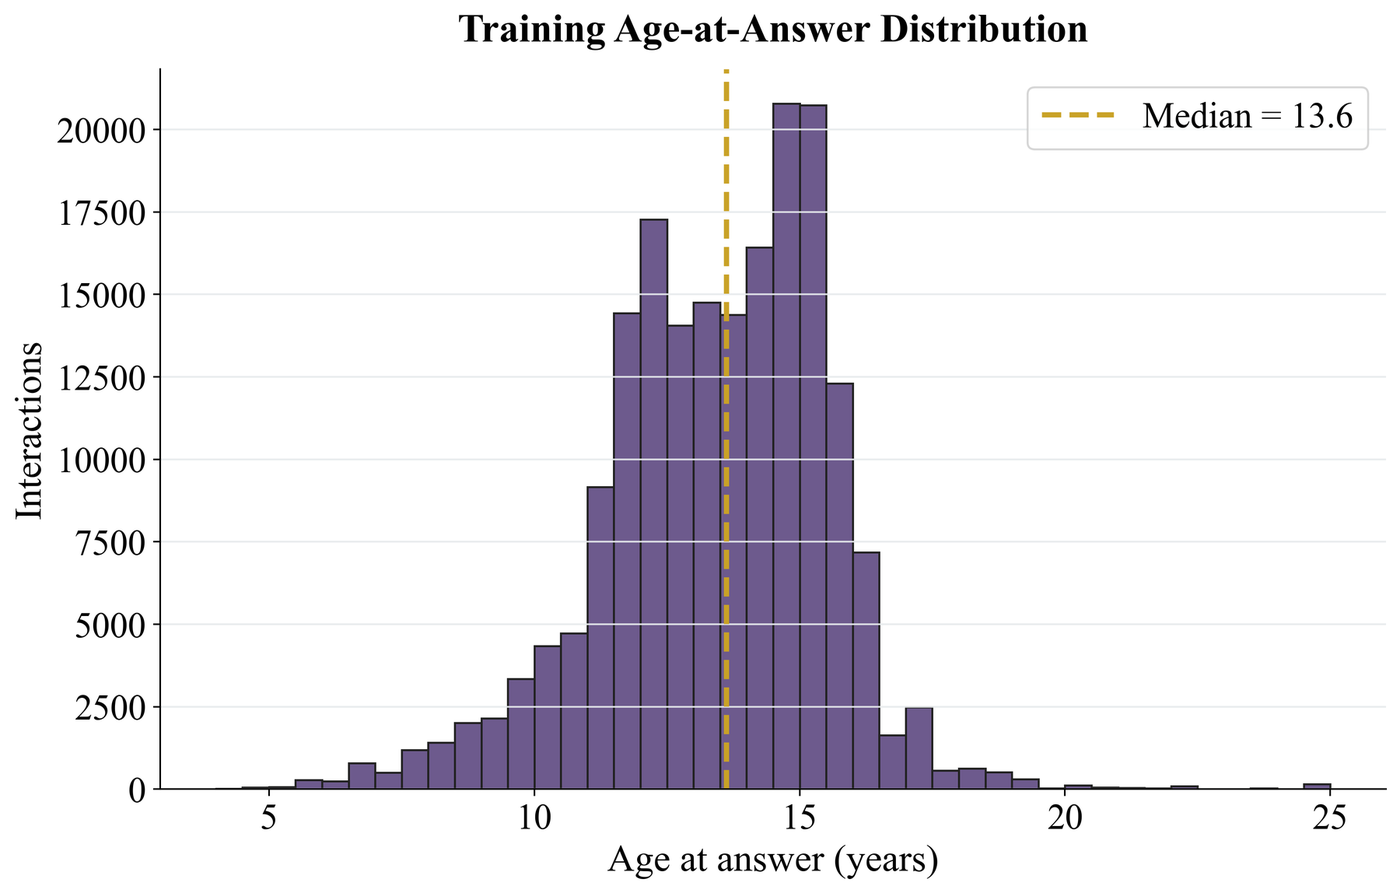

Saved figure: <repository_root>/figures/pretraining_age_distribution.png


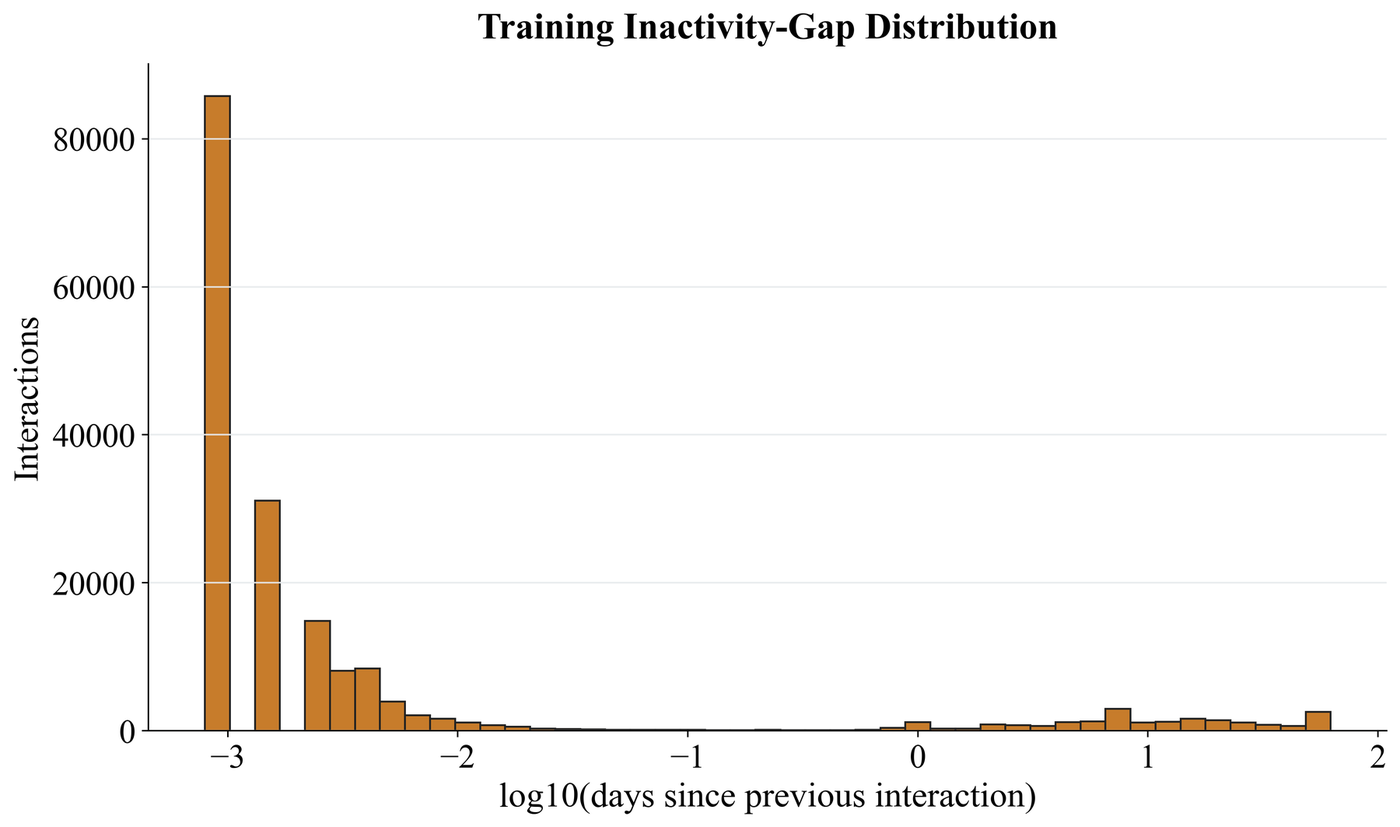

Saved figure: <repository_root>/figures/pretraining_time_gap_histogram.png


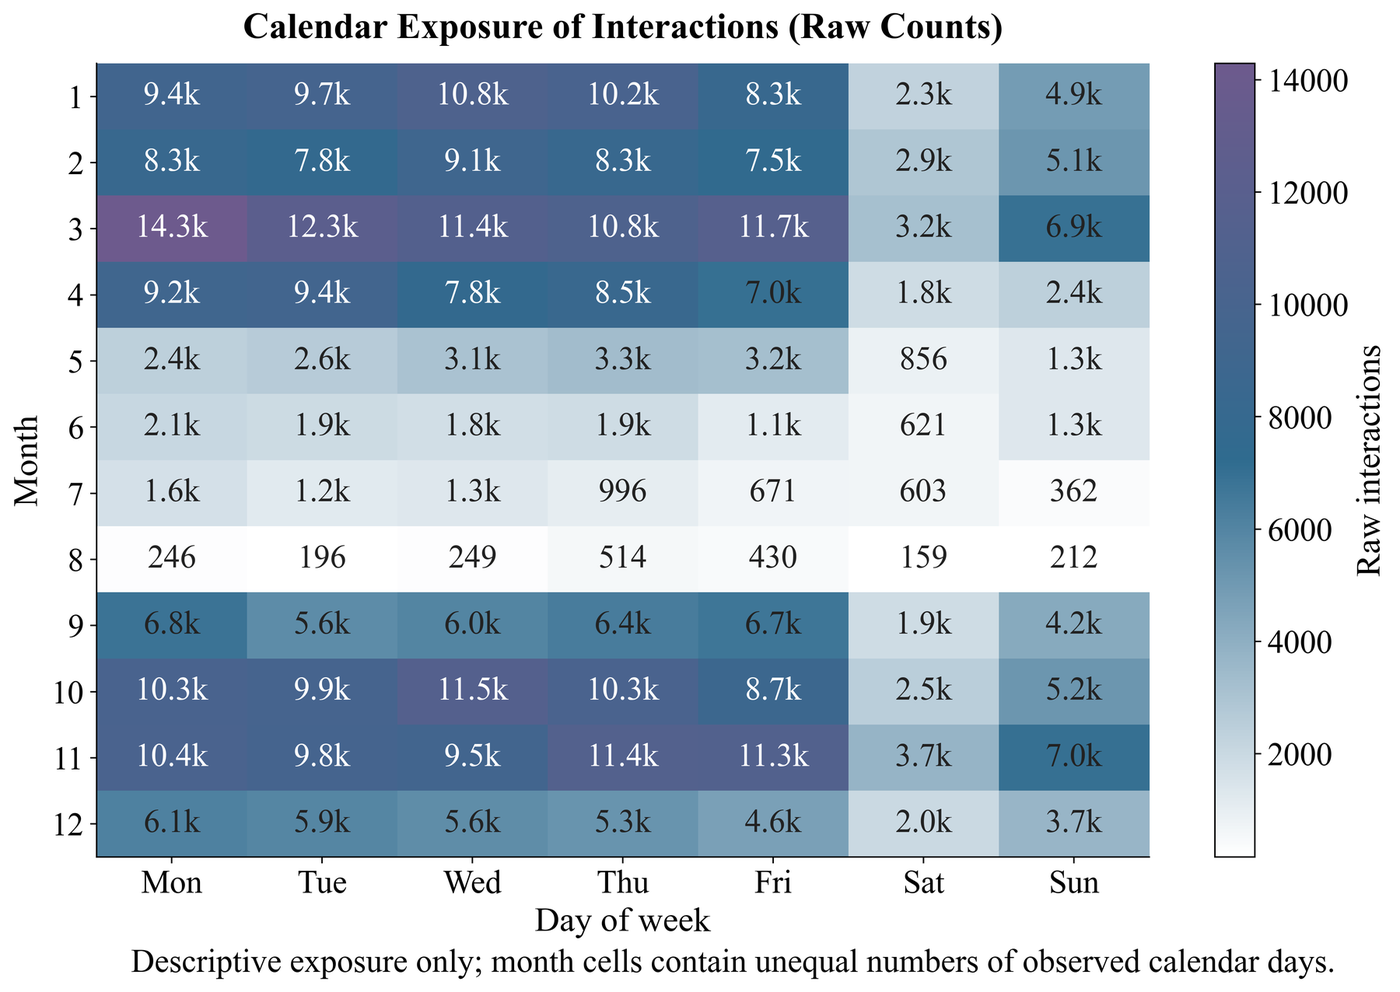

Saved figure: <repository_root>/figures/pretraining_calendar_heatmap.png


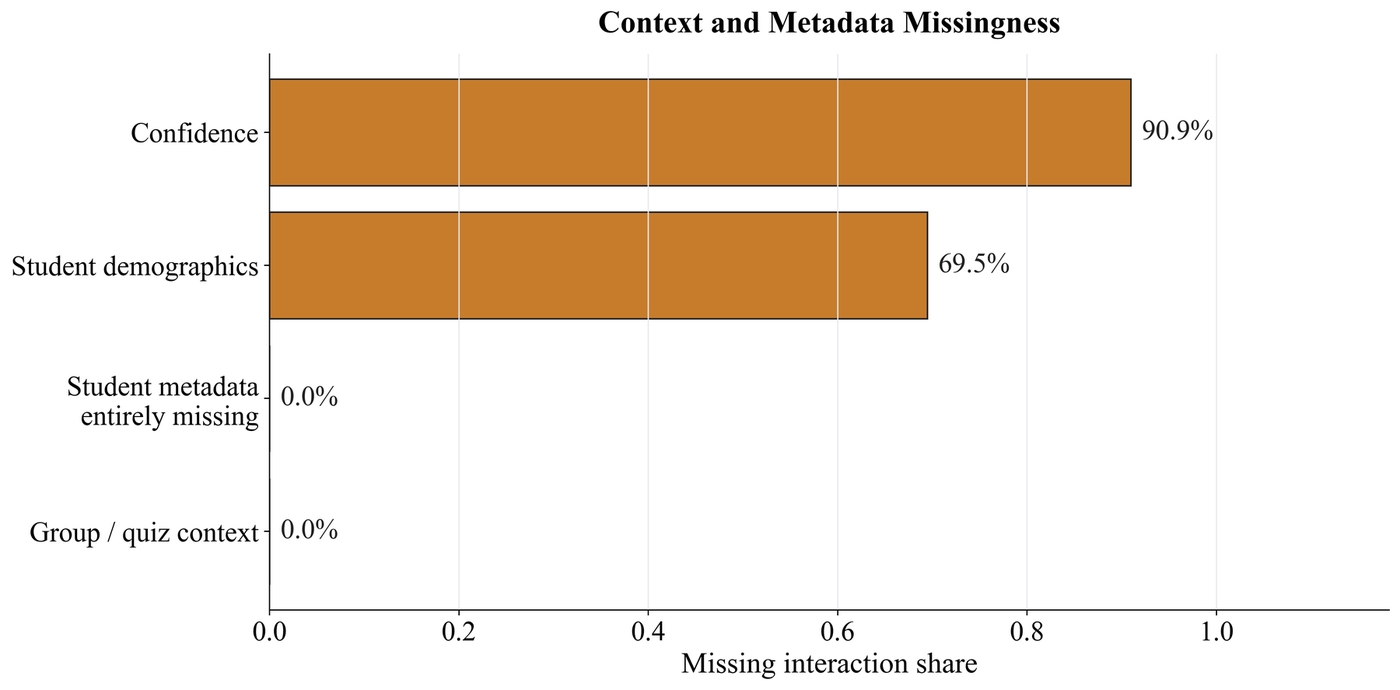

Saved figure: <repository_root>/figures/pretraining_context_missingness.png


In [13]:
# Missingness matrix across frozen splits.
miss_cols=[c for c in analysis_features if d[c].isna().any()]
miss_matrix=d.groupby("split_id")[miss_cols].apply(lambda g:g.isna().mean()).sort_index()
fig,ax=plt.subplots(figsize=(max(12,.8*len(miss_cols)),7)); im=ax.imshow(miss_matrix.values,aspect="auto",cmap=mpl.colors.LinearSegmentedColormap.from_list("missing",[PALETTE["white"],PALETTE["orange"],PALETTE["red"]]),vmin=0,vmax=max(.01,float(miss_matrix.values.max())))
for i in range(miss_matrix.shape[0]):
 for j in range(miss_matrix.shape[1]):
  value=float(miss_matrix.iloc[i,j]); ax.text(j,i,f"{value:.1%}",ha="center",va="center",fontsize=18,color=PALETTE["white"] if value>miss_matrix.values.max()*.55 else PALETTE["black"])
ax.set_xticks(range(len(miss_cols)),wrap_labels(miss_cols,18),rotation=50,ha="right",fontsize=18); ax.set_yticks(range(len(miss_matrix)),wrap_labels(miss_matrix.index,22),fontsize=18); ax.set_title("Feature Missingness by Evaluation Split",fontsize=20,fontweight="bold",pad=14); cb=fig.colorbar(im,ax=ax,pad=.02); cb.set_label("Missing rate",fontsize=19); cb.ax.tick_params(labelsize=18); save_and_show_figure(fig,"pretraining_missingness_matrix.png"); record_figure("pretraining_missingness_matrix.png","Where is feature completeness uneven across splits?","Predictor missingness only; labels not used")

# Age distribution.
age=train_eda.age_at_answer.dropna()
fig,ax=plt.subplots(figsize=(11,6.5)); ax.hist(age,bins=np.arange(math.floor(age.min()),math.ceil(age.max())+.5,.5),color=PALETTE["purple"],edgecolor=PALETTE["black"]); finish_axes(ax,"Training Age-at-Answer Distribution","Age at answer (years)","Interactions",grid_axis="y"); ax.axvline(age.median(),color=PALETTE["gold"],linewidth=2.6,linestyle="--",label=f"Median = {age.median():.1f}"); ax.legend(fontsize=18); save_and_show_figure(fig,"pretraining_age_distribution.png"); record_figure("pretraining_age_distribution.png","Which ages dominate the training interactions?","Training metadata only")

# Time-gap distribution, clipped for readability.
gaps=train_eda.days_since_previous_interaction.dropna(); positive=gaps[gaps>0]; clipped=positive.clip(upper=positive.quantile(.99))
fig,ax=plt.subplots(figsize=(12,6.5)); ax.hist(np.log10(clipped+1e-4),bins=45,color=PALETTE["orange"],edgecolor=PALETTE["black"]); finish_axes(ax,"Training Inactivity-Gap Distribution","log10(days since previous interaction)","Interactions",grid_axis="y"); save_and_show_figure(fig,"pretraining_time_gap_histogram.png"); record_figure("pretraining_time_gap_histogram.png","How variable are gaps between learner interactions?","Training timestamps only")

# Calendar heatmap.
calendar=d.groupby([d.date_answered.dt.month,d.date_answered.dt.dayofweek]).size().unstack(fill_value=0).reindex(index=range(1,13),columns=range(7),fill_value=0)
fig,ax=plt.subplots(figsize=(13,8)); im=ax.imshow(calendar.values,aspect="auto",cmap=mpl.colors.LinearSegmentedColormap.from_list("calendar",[PALETTE["white"],PALETTE["blue"],PALETTE["purple"]]))
for i in range(calendar.shape[0]):
 for j in range(calendar.shape[1]):
  value=int(calendar.iloc[i,j]); label=f"{value/1000:.1f}k" if value>=1000 else f"{value:,}"; ax.text(j,i,label,ha="center",va="center",fontsize=18,color=PALETTE["white"] if value>calendar.values.max()*.52 else PALETTE["black"])
ax.set_xticks(range(7),["Mon","Tue","Wed","Thu","Fri","Sat","Sun"],fontsize=18); ax.set_yticks(range(12),[str(i) for i in range(1,13)],fontsize=18); ax.set_xlabel("Day of week",fontsize=19); ax.set_ylabel("Month",fontsize=19); ax.set_title("Calendar Exposure of Interactions (Raw Counts)",fontsize=20,fontweight="bold",pad=14); cb=fig.colorbar(im,ax=ax); cb.set_label("Raw interactions",fontsize=19); cb.ax.tick_params(labelsize=18); fig.text(.5,.01,"Descriptive exposure only; month cells contain unequal numbers of observed calendar days.",ha="center",fontsize=18); fig.subplots_adjust(bottom=.12); save_and_show_figure(fig,"pretraining_calendar_heatmap.png"); record_figure("pretraining_calendar_heatmap.png","Where is raw interaction exposure concentrated?","Raw timestamp counts; unequal calendar-day exposure is explicitly noted")

# Context completeness.
context_missing=pd.Series({"Confidence":d.missing_confidence.mean(),"Student demographics":d.missing_demographics.mean(),"Group / quiz context":d.missing_context_metadata.mean(),"Student metadata entirely missing":d.missing_student_metadata.mean()}).sort_values()
fig,ax=plt.subplots(figsize=(13,6.5)); ax.barh(wrap_labels(context_missing.index,24),context_missing.values,color=PALETTE["orange"],edgecolor=PALETTE["black"]); label_horizontal(ax,fmt="{:.1%}"); finish_axes(ax,"Context and Metadata Missingness","Missing interaction share"); ax.set_xlim(0,max(.05,context_missing.max()*1.3)); save_and_show_figure(fig,"pretraining_context_missingness.png"); record_figure("pretraining_context_missingness.png","Which context views are least complete?","All cohort missingness flags; labels not used")

## 13. Mathematical concepts, hierarchy, split design, and cold start

Visualize subject coverage, concept difficulty, hierarchy depth, and the exact evaluation design that addresses temporal and cold-start generalization. Use ranked bars, a volume–difficulty scatter, hierarchy-depth bars, split-size comparisons, and explicit cold-start rates.

Leakage control: Concept difficulty is calculated from train-only mappings; split/cold-start figures use identifiers and counts only.

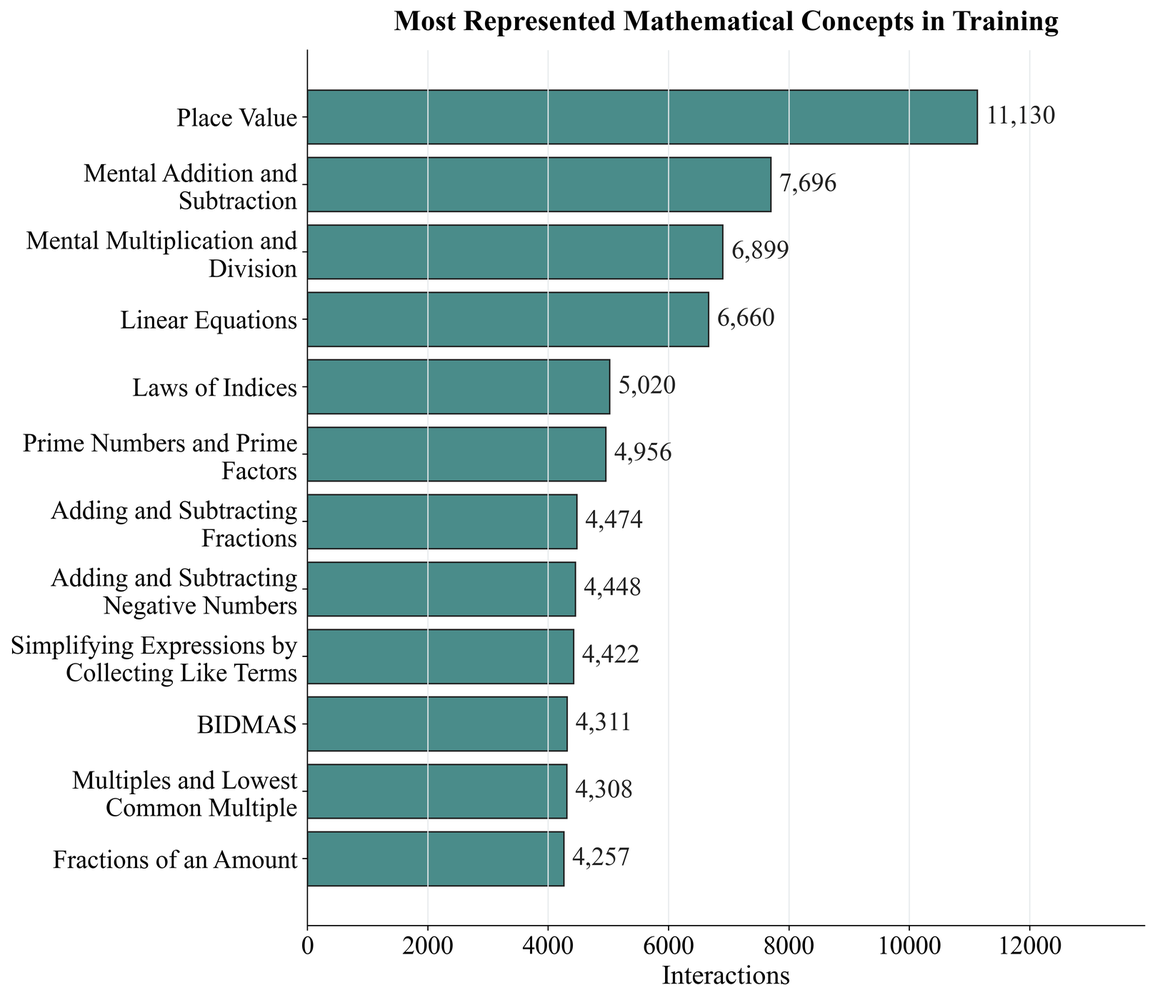

Saved figure: <repository_root>/figures/pretraining_subject_coverage.png


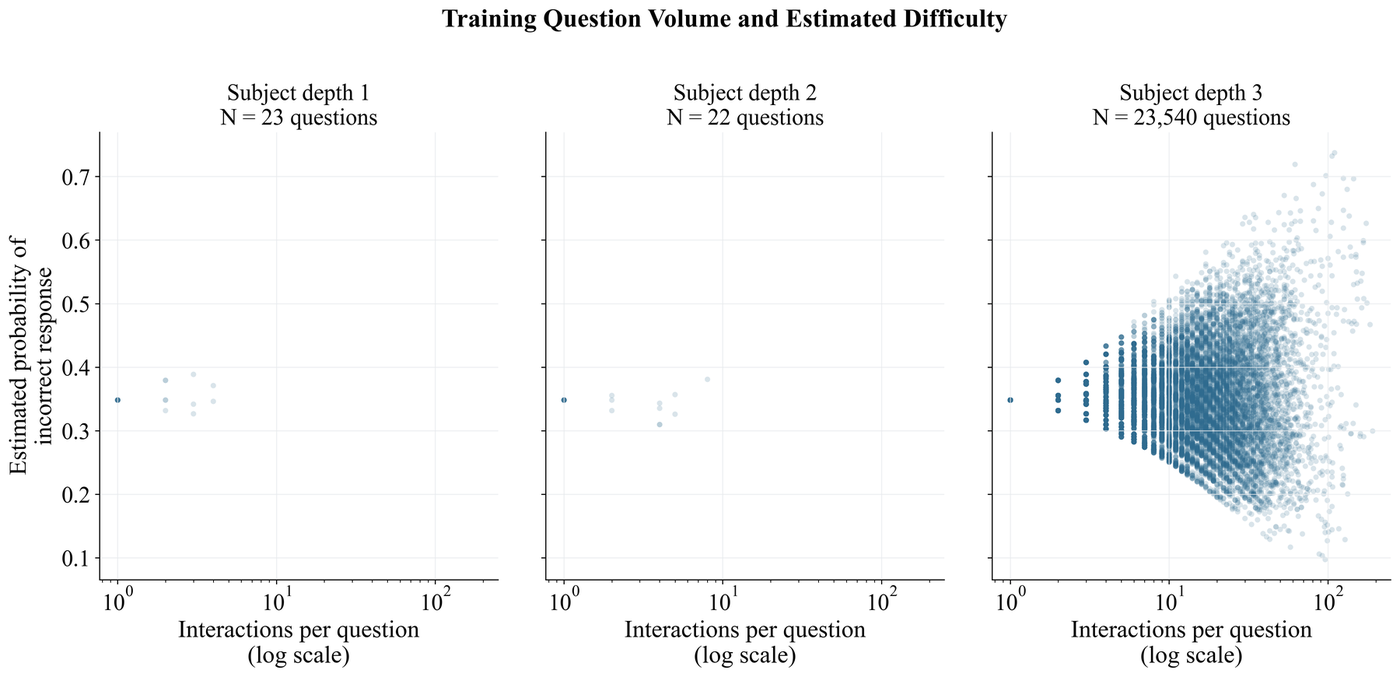

Saved figure: <repository_root>/figures/pretraining_question_difficulty_scatter.png


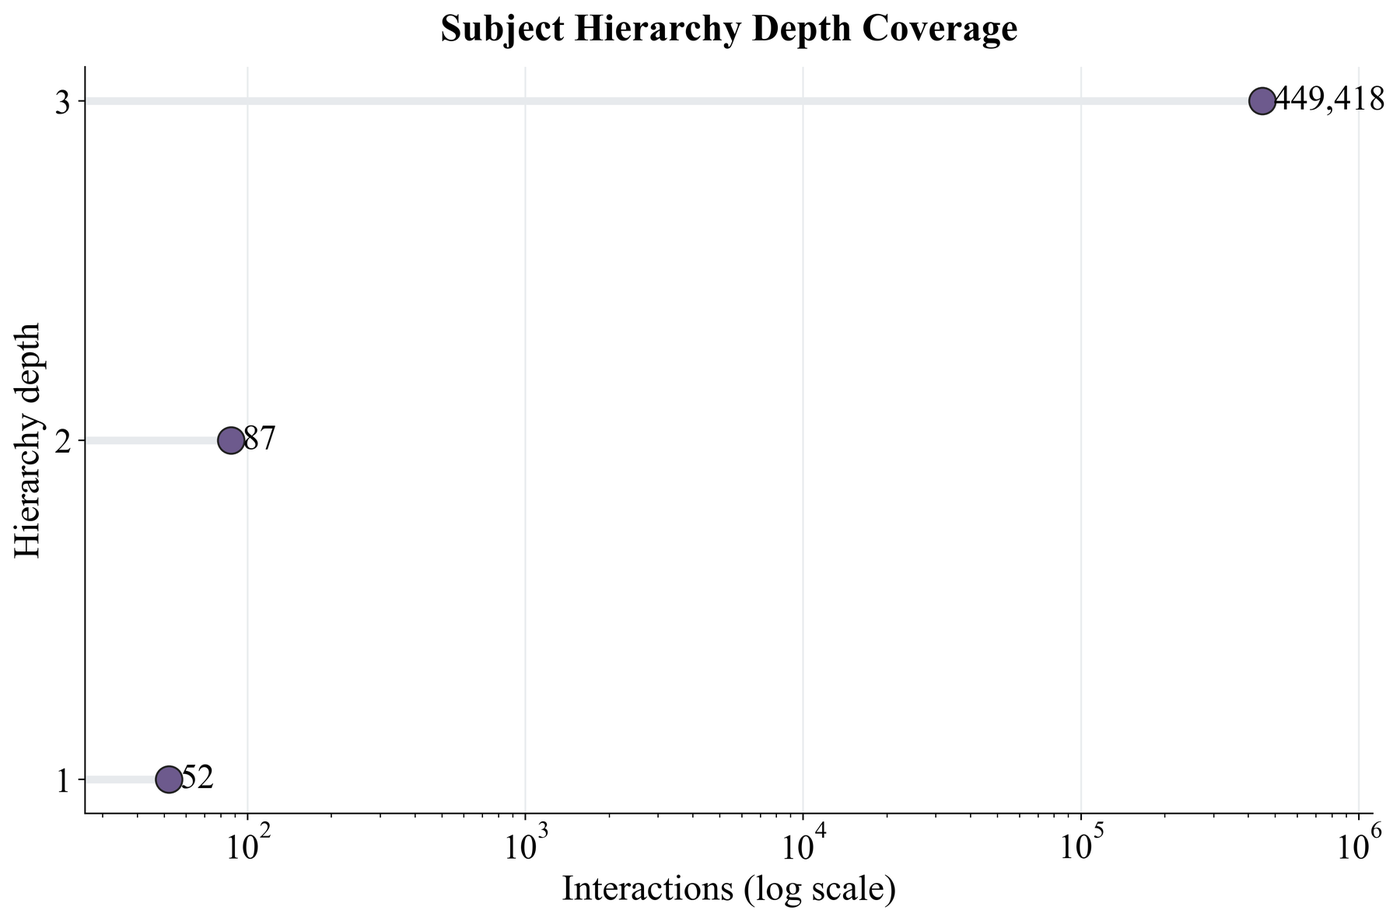

Saved figure: <repository_root>/figures/pretraining_subject_hierarchy_depth.png


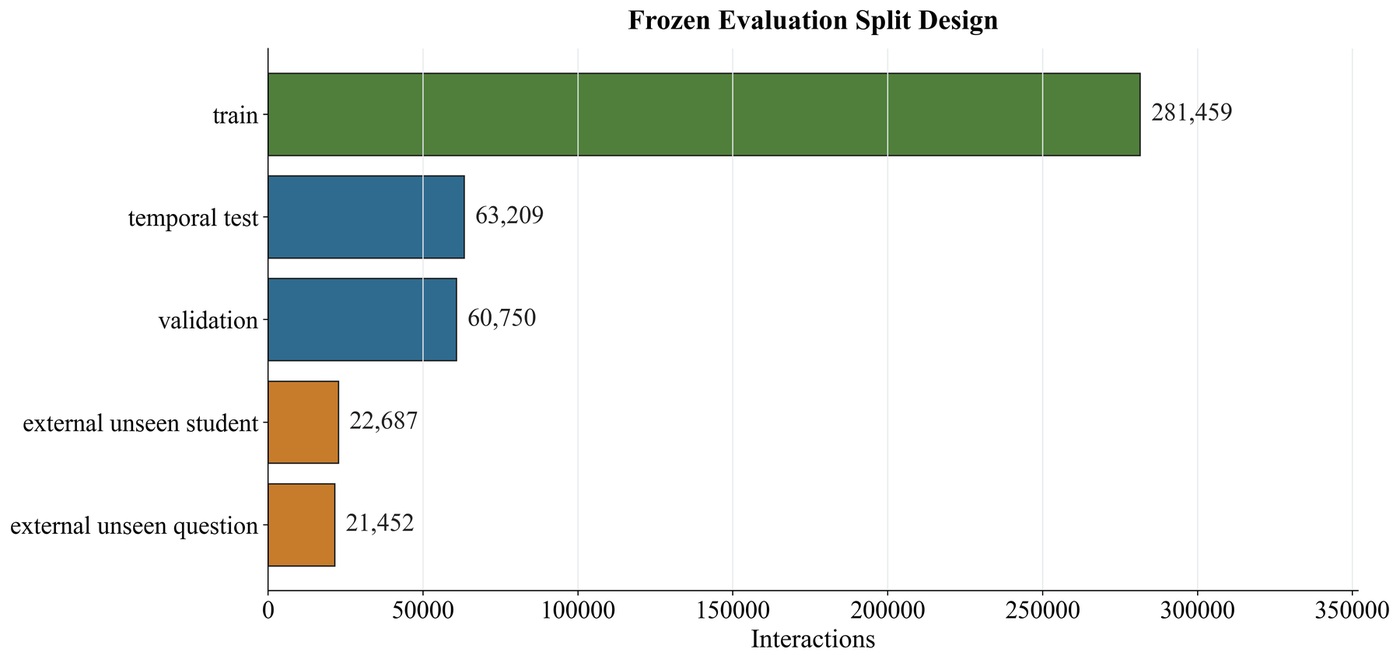

Saved figure: <repository_root>/figures/pretraining_split_design.png


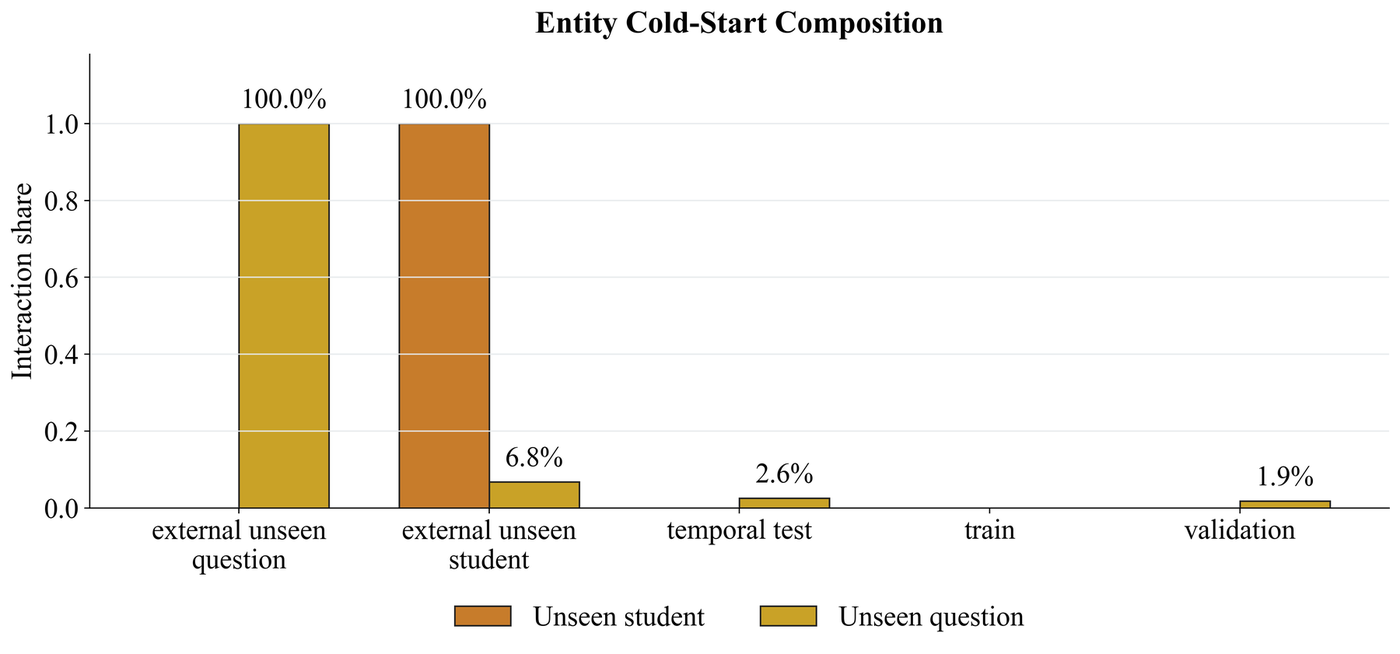

Saved figure: <repository_root>/figures/pretraining_cold_start_design.png


In [14]:
# Top mathematical subjects by training interactions.
subject_cov=train_eda.primary_subject_name.value_counts().head(12).sort_values()
fig,ax=plt.subplots(figsize=(15,11)); ax.barh(wrap_labels(subject_cov.index,26),subject_cov.values,color=PALETTE["teal"],edgecolor=PALETTE["black"]); label_horizontal(ax); finish_axes(ax,"Most Represented Mathematical Concepts in Training","Interactions"); ax.set_xlim(0,subject_cov.max()*1.25); fig.subplots_adjust(left=.36); save_and_show_figure(fig,"pretraining_subject_coverage.png"); record_figure("pretraining_subject_coverage.png","Which mathematical concepts dominate training?","Top 12 concepts by train-only interaction count")

# Train-only item volume vs difficulty.
item_diag=train_eda.groupby("question_id").agg(interactions=("is_correct","size"),difficulty=("question_difficulty","mean"),depth=("subject_depth","median")).reset_index()
depth_levels=sorted(item_diag.depth.dropna().unique()); fig,axes=plt.subplots(1,len(depth_levels),figsize=(18,7),sharex=True,sharey=True,squeeze=False)
for ax,depth in zip(axes.ravel(),depth_levels):
 g=item_diag[item_diag.depth.eq(depth)]; ax.scatter(g.interactions,g.difficulty,s=18,alpha=.18,color=PALETTE["blue"],edgecolors="none",rasterized=True); ax.set_xscale("log"); ax.set_title(f"Subject depth {int(depth)}\nN = {len(g):,} questions",fontsize=18); ax.set_xlabel("Interactions per question\n(log scale)",fontsize=19); ax.grid(color=PALETTE["light_gray"],alpha=.7)
axes[0,0].set_ylabel("Estimated probability of\nincorrect response",fontsize=19); fig.suptitle("Training Question Volume and Estimated Difficulty",fontsize=20,fontweight="bold",y=.99); fig.subplots_adjust(top=.80,wspace=.12); save_and_show_figure(fig,"pretraining_question_difficulty_scatter.png"); record_figure("pretraining_question_difficulty_scatter.png","Does item difficulty vary with exposure volume?","Train-only item diagnostics; faceted by discrete subject depth")

# Hierarchy depth coverage.
depth_counts=d.subject_depth.value_counts().sort_index()
fig,ax=plt.subplots(figsize=(12,7)); y=np.arange(len(depth_counts)); ax.hlines(y,1,depth_counts.values,color=PALETTE["light_gray"],linewidth=4); ax.scatter(depth_counts.values,y,s=190,color=PALETTE["purple"],edgecolor=PALETTE["black"],zorder=3); ax.set_yticks(y,depth_counts.index.astype(int).astype(str))
for yi,v in zip(y,depth_counts): ax.text(v*1.10,yi,f"{v:,}",ha="left",va="center",fontsize=18,clip_on=False)
ax.set_xscale("log"); finish_axes(ax,"Subject Hierarchy Depth Coverage","Interactions (log scale)","Hierarchy depth",grid_axis="x"); ax.set_xlim(max(.8,depth_counts.min()/2),depth_counts.max()*2.5); save_and_show_figure(fig,"pretraining_subject_hierarchy_depth.png"); record_figure("pretraining_subject_hierarchy_depth.png","How deeply are mathematical concepts represented?","Hierarchy metadata; log-scale dot plot with exact counts")

# Split design counts.
split_plot=split_summary.set_index("split_id").interactions.sort_values()
colors=[PALETTE["orange"] if x.startswith("external") else PALETTE["green"] if x=="train" else PALETTE["blue"] for x in split_plot.index]
fig,ax=plt.subplots(figsize=(14,7)); ax.barh(wrap_labels(split_plot.index,26),split_plot.values,color=colors,edgecolor=PALETTE["black"]); label_horizontal(ax); finish_axes(ax,"Frozen Evaluation Split Design","Interactions"); ax.set_xlim(0,split_plot.max()*1.25); save_and_show_figure(fig,"pretraining_split_design.png"); record_figure("pretraining_split_design.png","How much evidence is allocated to each evaluation scenario?","Split identifiers and counts only")

# Cold-start rates.
cold=cold_start_summary.set_index("split_id")[["student_cold_start_rate","question_cold_start_rate"]]
fig,ax=plt.subplots(figsize=(15,7)); x=np.arange(len(cold)); width=.36; b1=ax.bar(x-width/2,cold.student_cold_start_rate,width,label="Unseen student",color=PALETTE["orange"],edgecolor=PALETTE["black"]); b2=ax.bar(x+width/2,cold.question_cold_start_rate,width,label="Unseen question",color=PALETTE["gold"],edgecolor=PALETTE["black"])
for bars in [b1,b2]:
 for b in bars:
  if b.get_height()>=.005: ax.text(b.get_x()+b.get_width()/2,b.get_height()+.025,f"{b.get_height():.1%}",ha="center",va="bottom",fontsize=18)
ax.set_xticks(x,wrap_labels(cold.index,22),fontsize=18); ax.set_ylim(0,1.18); finish_axes(ax,"Entity Cold-Start Composition",ylabel="Interaction share",grid_axis="y"); place_legend_below(ax,2); fig.subplots_adjust(bottom=.30); save_and_show_figure(fig,"pretraining_cold_start_design.png"); record_figure("pretraining_cold_start_design.png","Are external sets truly entity-cold?","Train-fitted entity membership; labels not used")

## 14. Correlation, association, distribution-shift, and sequence matrices

Reveal redundancy, nonlinear predictive signal, covariate shift, and sequence-length structure before model fitting. Produce a Spearman correlation matrix, train-only mutual-information ranking, PSI matrix, sequence-length histogram, and missingness co-occurrence matrix.

Leakage control: Mutual information uses train labels only; all other matrices are predictor- or sequence-only.

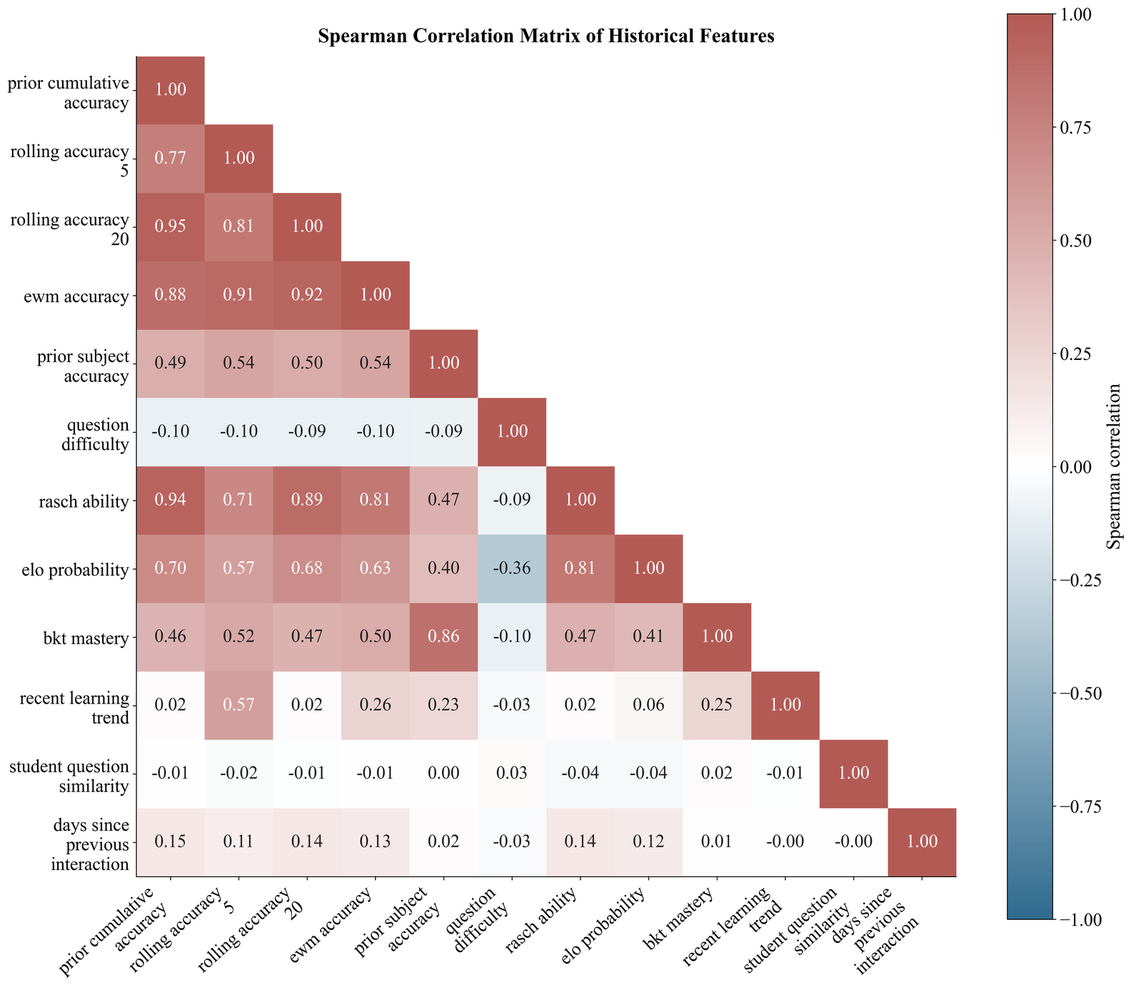

Saved figure: <repository_root>/figures/pretraining_feature_correlation_matrix.png


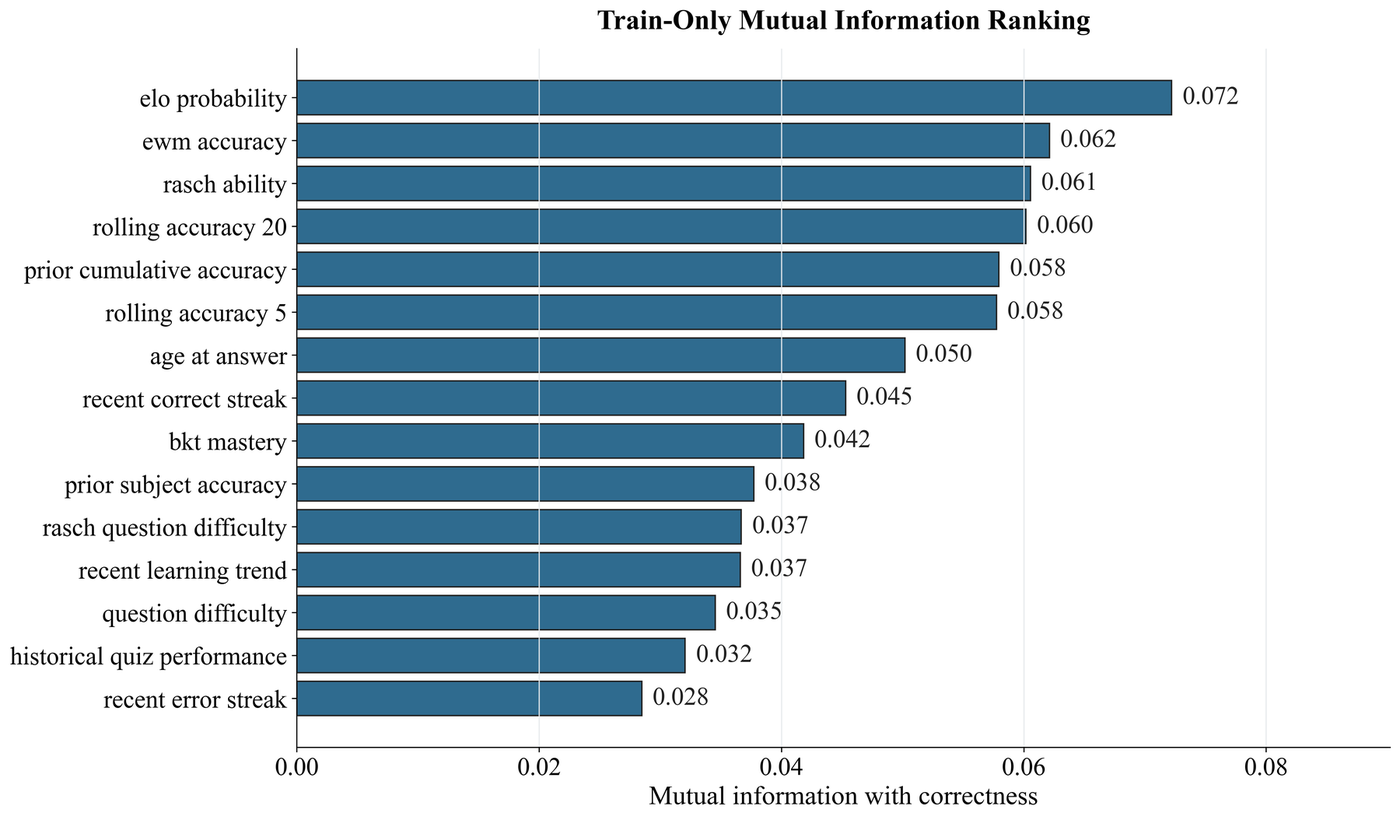

Saved figure: <repository_root>/figures/pretraining_mutual_information_ranking.png


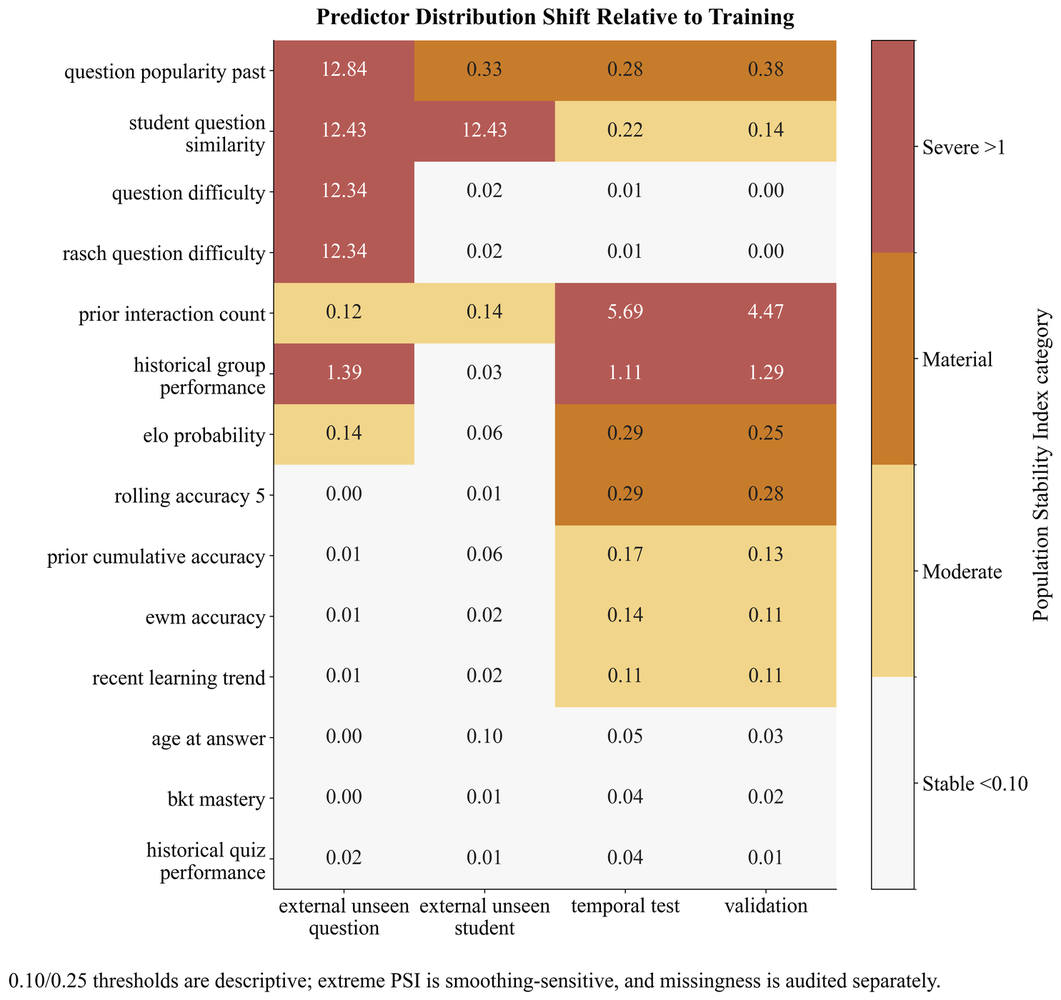

Saved figure: <repository_root>/figures/pretraining_distribution_shift_matrix.png


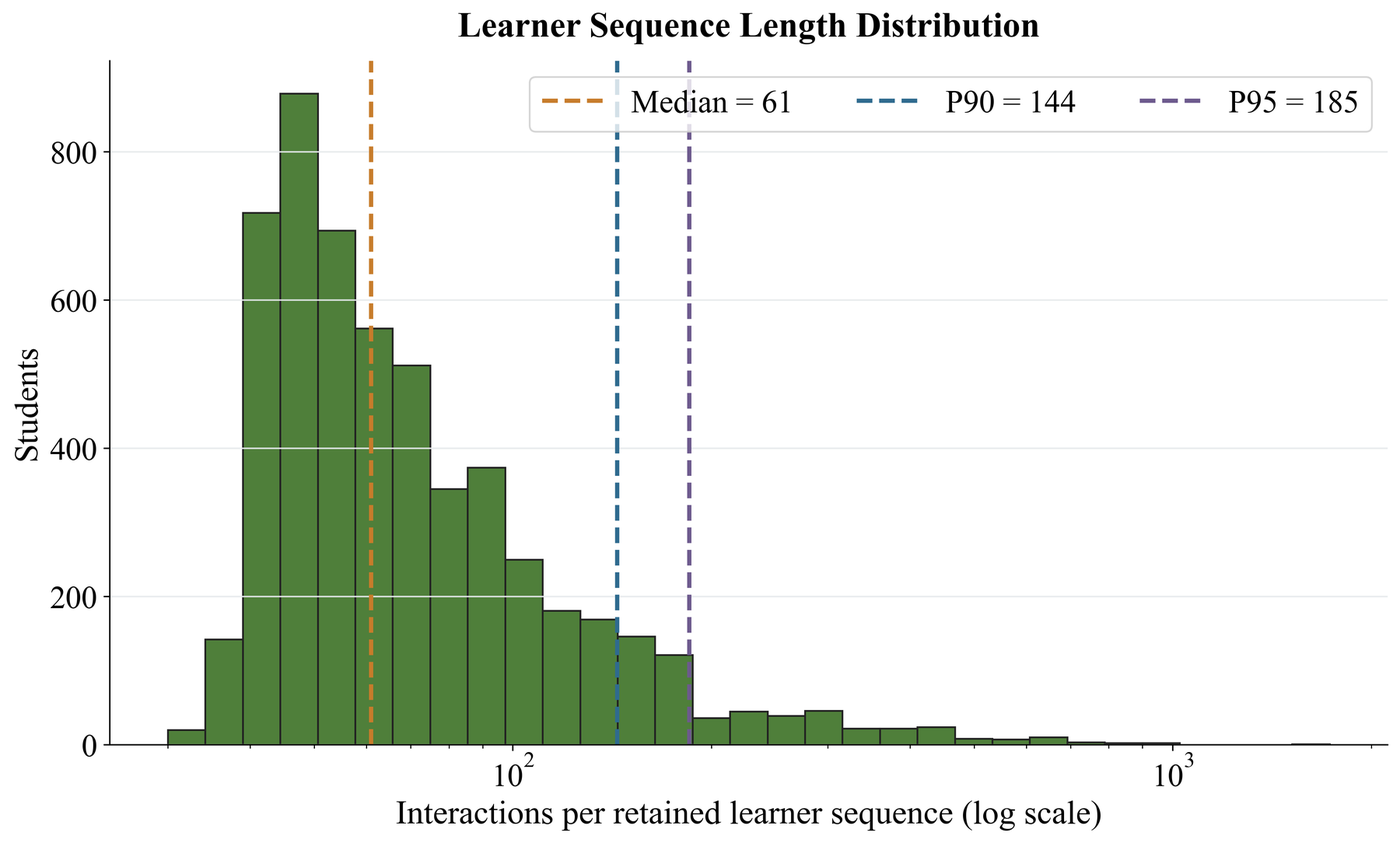

Saved figure: <repository_root>/figures/pretraining_sequence_length_distribution.png


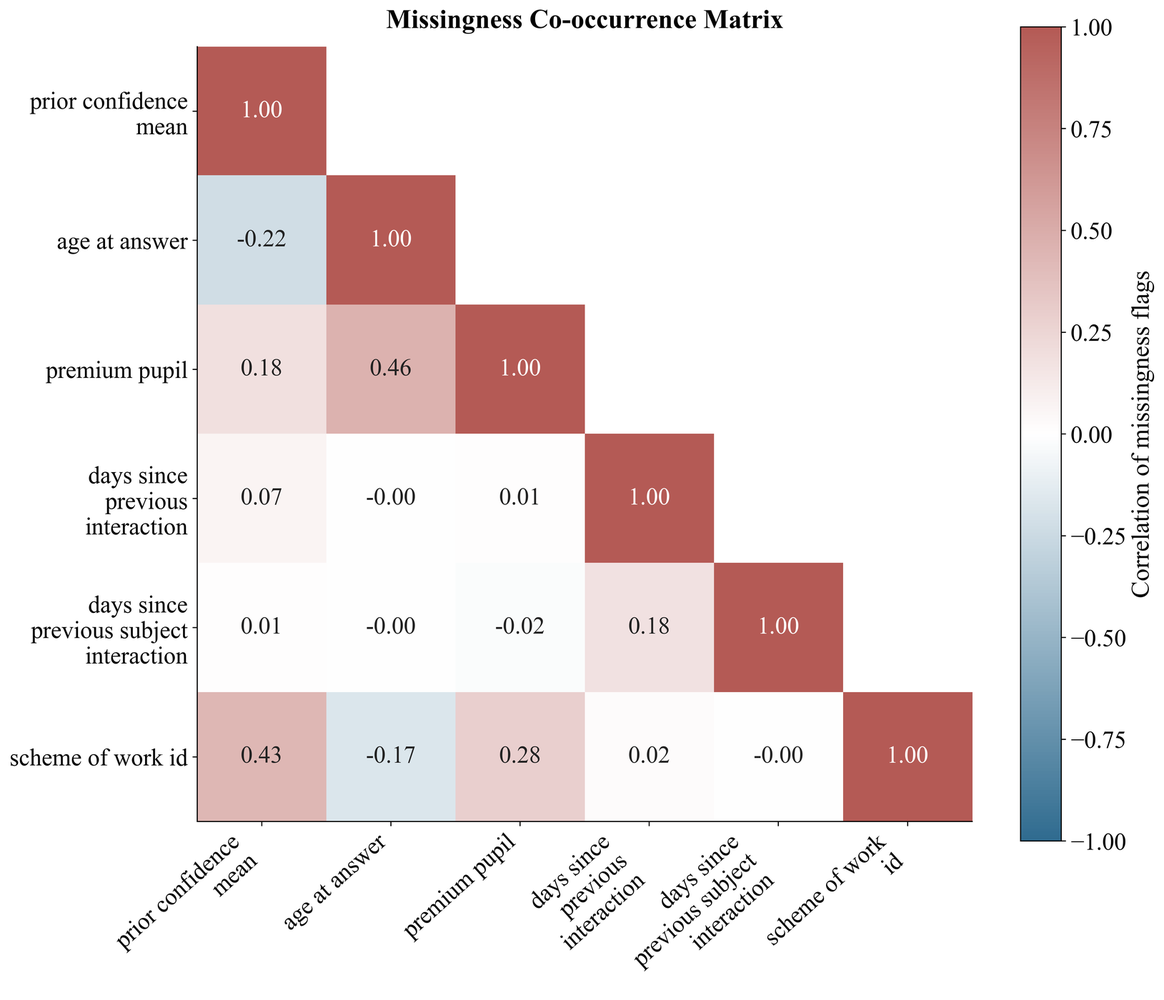

Saved figure: <repository_root>/figures/pretraining_missingness_cooccurrence_matrix.png
Saved visualization index: <repository_root>/artifacts/pretraining_visualization_index.csv


,filename,analytical_question,evidence_boundary,renderer,font,dpi
0,pretraining_dataset_coverage.png,How broad is the common research cohort?,All cohort rows; log-scale dot plot with exact...,Matplotlib,Times New Roman 18–20 pt,350
1,pretraining_target_distribution_train.png,Is the training target imbalanced?,Training labels only,Matplotlib,Times New Roman 18–20 pt,350
2,pretraining_interaction_timeline.png,How does interaction volume vary over time?,All cohort timestamps; labels not used,Matplotlib,Times New Roman 18–20 pt,350
3,pretraining_student_activity_histogram.png,How long and skewed are learner histories?,All cohort identifiers; labels not used,Matplotlib,Times New Roman 18–20 pt,350
4,pretraining_question_activity_histogram.png,How sparse and long-tailed is item exposure?,All cohort identifiers; labels not used,Matplotlib,Times New Roman 18–20 pt,350
5,pretraining_missingness_matrix.png,Where is feature completeness uneven across sp...,Predictor missingness only; labels not used,Matplotlib,Times New Roman 18–20 pt,350
6,pretraining_age_distribution.png,Which ages dominate the training interactions?,Training metadata only,Matplotlib,Times New Roman 18–20 pt,350
7,pretraining_time_gap_histogram.png,How variable are gaps between learner interact...,Training timestamps only,Matplotlib,Times New Roman 18–20 pt,350
8,pretraining_calendar_heatmap.png,Where is raw interaction exposure concentrated?,Raw timestamp counts; unequal calendar-day exp...,Matplotlib,Times New Roman 18–20 pt,350
9,pretraining_context_missingness.png,Which context views are least complete?,All cohort missingness flags; labels not used,Matplotlib,Times New Roman 18–20 pt,350


In [15]:
# Spearman correlation matrix.
corr_features=["prior_cumulative_accuracy","rolling_accuracy_5","rolling_accuracy_20","ewm_accuracy","prior_subject_accuracy","question_difficulty","rasch_ability","elo_probability","bkt_mastery","recent_learning_trend","student_question_similarity","days_since_previous_interaction"]
corr=train_eda[corr_features].corr(method="spearman")
corr_mask=np.triu(np.ones_like(corr,dtype=bool),k=1); corr_cmap=mpl.colors.LinearSegmentedColormap.from_list("corr",[PALETTE["blue"],PALETTE["white"],PALETTE["red"]]); corr_cmap.set_bad(PALETTE["white"])
fig,ax=plt.subplots(figsize=(18,16)); im=ax.imshow(np.ma.array(corr.values,mask=corr_mask),vmin=-1,vmax=1,cmap=corr_cmap); ax.set_xticks(range(len(corr)),wrap_labels(corr.columns,16),rotation=42,ha="right",fontsize=18); ax.set_yticks(range(len(corr)),wrap_labels(corr.index,16),fontsize=18)
for i in range(len(corr)):
 for j in range(i+1): ax.text(j,i,f"{corr.iloc[i,j]:.2f}",ha="center",va="center",fontsize=18,color=PALETTE["white"] if abs(corr.iloc[i,j])>.55 else PALETTE["black"])
ax.set_title("Spearman Correlation Matrix of Historical Features",fontsize=20,fontweight="bold",pad=14); cb=fig.colorbar(im,ax=ax); cb.set_label("Spearman correlation",fontsize=19); cb.ax.tick_params(labelsize=18); save_and_show_figure(fig,"pretraining_feature_correlation_matrix.png"); record_figure("pretraining_feature_correlation_matrix.png","Which engineered histories are redundant or complementary?","Training predictors only")

# Mutual information ranking.
mi_plot=association_summary.nlargest(15,"mutual_information").sort_values("mutual_information")
fig,ax=plt.subplots(figsize=(14,9)); ax.barh(wrap_labels(mi_plot.feature,30),mi_plot.mutual_information,color=PALETTE["blue"],edgecolor=PALETTE["black"]); label_horizontal(ax,fmt="{:.3f}"); finish_axes(ax,"Train-Only Mutual Information Ranking","Mutual information with correctness"); ax.set_xlim(0,max(.001,mi_plot.mutual_information.max()*1.25)); save_and_show_figure(fig,"pretraining_mutual_information_ranking.png"); record_figure("pretraining_mutual_information_ranking.png","Which predictors contain the strongest nonlinear train-only signal?","Training labels only")

# PSI matrix.
psi_matrix=shift_summary.pivot(index="split",columns="feature",values="psi").fillna(0)
psi_cols=shift_summary.groupby("feature").psi.max().nlargest(14).index; psi_view=psi_matrix[psi_cols].T
psi_max=float(psi_view.values.max()); psi_upper=max(1.01,psi_max+.01); psi_bounds=[0,.10,.25,1.0,psi_upper]; psi_cmap=mpl.colors.ListedColormap(["#F7F7F7","#F1D58A",PALETTE["orange"],PALETTE["red"]]); psi_norm=mpl.colors.BoundaryNorm(psi_bounds,psi_cmap.N)
fig,ax=plt.subplots(figsize=(15,13)); im=ax.imshow(psi_view.values,aspect="auto",cmap=psi_cmap,norm=psi_norm)
for i in range(psi_view.shape[0]):
 for j in range(psi_view.shape[1]):
  value=float(psi_view.iloc[i,j]); ax.text(j,i,f"{value:.2f}",ha="center",va="center",fontsize=18,color=PALETTE["white"] if value>=1 else PALETTE["black"])
ax.set_xticks(range(psi_view.shape[1]),wrap_labels(psi_view.columns,20),fontsize=18); ax.set_yticks(range(psi_view.shape[0]),wrap_labels(psi_view.index,25),fontsize=18); ax.set_title("Predictor Distribution Shift Relative to Training",fontsize=20,fontweight="bold",pad=14); cb=fig.colorbar(im,ax=ax,boundaries=psi_bounds,ticks=[.05,.175,.625,(1+psi_upper)/2]); cb.ax.set_yticklabels(["Stable <0.10","Moderate","Material","Severe >1"],fontsize=18); cb.set_label("Population Stability Index category",fontsize=19); fig.text(.5,.01,"0.10/0.25 thresholds are descriptive; extreme PSI is smoothing-sensitive, and missingness is validated separately.",ha="center",fontsize=18); fig.subplots_adjust(left=.34,bottom=.10); save_and_show_figure(fig,"pretraining_distribution_shift_matrix.png"); record_figure("pretraining_distribution_shift_matrix.png","Where is covariate shift strongest?","Predictors only; threshold-aware PSI categories with exact values and smoothing caveat")

# Sequence-length distribution.
seq_len=sequences.question_ids.map(len); seq_q=seq_len.quantile([.5,.9,.95])
seq_bins=np.unique(np.logspace(np.log10(max(1,seq_len.min())),np.log10(seq_len.max()),32)); fig,ax=plt.subplots(figsize=(13,7)); ax.hist(seq_len,bins=seq_bins,color=PALETTE["green"],edgecolor=PALETTE["black"]); ax.set_xscale("log"); finish_axes(ax,"Learner Sequence Length Distribution","Interactions per retained learner sequence (log scale)","Students",grid_axis="y")
for value,label,color in [(seq_q.loc[.5],"Median",PALETTE["orange"]),(seq_q.loc[.9],"P90",PALETTE["blue"]),(seq_q.loc[.95],"P95",PALETTE["purple"])]: ax.axvline(value,color=color,linewidth=2.4,linestyle="--",label=f"{label} = {value:.0f}")
ax.legend(fontsize=18,ncol=3,loc="upper right"); save_and_show_figure(fig,"pretraining_sequence_length_distribution.png"); record_figure("pretraining_sequence_length_distribution.png","What context lengths must sequential models support?","Sequence identifiers only; log scale with median, P90, and P95")

# Missingness co-occurrence matrix.
missing_features=["prior_confidence_mean","age_at_answer","premium_pupil","days_since_previous_interaction","days_since_previous_subject_interaction","scheme_of_work_id"]
missing_features=[c for c in missing_features if c in d.columns]
miss_corr=d[missing_features].isna().astype(int).corr().fillna(0)
miss_mask=np.triu(np.ones_like(miss_corr,dtype=bool),k=1); miss_cmap=mpl.colors.LinearSegmentedColormap.from_list("misscorr",[PALETTE["blue"],PALETTE["white"],PALETTE["red"]]); miss_cmap.set_bad(PALETTE["white"])
fig,ax=plt.subplots(figsize=(13,11)); im=ax.imshow(np.ma.array(miss_corr.values,mask=miss_mask),vmin=-1,vmax=1,cmap=miss_cmap); ax.set_xticks(range(len(miss_corr)),wrap_labels(miss_corr.columns,16),rotation=42,ha="right",fontsize=18); ax.set_yticks(range(len(miss_corr)),wrap_labels(miss_corr.index,18),fontsize=18)
for i in range(len(miss_corr)):
 for j in range(i+1):
  value=float(miss_corr.iloc[i,j]); ax.text(j,i,f"{value:.2f}",ha="center",va="center",fontsize=18,color=PALETTE["white"] if abs(value)>.55 else PALETTE["black"])
ax.set_title("Missingness Co-occurrence Matrix",fontsize=20,fontweight="bold",pad=14); cb=fig.colorbar(im,ax=ax); cb.set_label("Correlation of missingness flags",fontsize=19); cb.ax.tick_params(labelsize=18); save_and_show_figure(fig,"pretraining_missingness_cooccurrence_matrix.png"); record_figure("pretraining_missingness_cooccurrence_matrix.png","Which missing data patterns co-occur?","Missingness indicators only")

visualization_index_df=pd.DataFrame(visualization_index); viz_index_path=ROOT/"artifacts/pretraining_visualization_index.csv"; visualization_index_df.to_csv(viz_index_path,index=False)
print(f"Saved visualization index: {viz_index_path}")
display(visualization_index_df)